In [1]:
# =========================
# IMPORTS GENERALES
# IMPORT GENERALI
# =========================

# pandas y numpy se utilizan para trabajar con datos tabulares
# y realizar operaciones numéricas de forma eficiente.
# pandas e numpy si usano per lavorare con dati tabellari
# e per eseguire operazioni numeriche in modo efficiente.
import pandas as pd
import numpy as np

# matplotlib y seaborn se utilizan para crear gráficas y visualizaciones
# que ayuden a interpretar mejor el comportamiento de los datos.
# matplotlib e seaborn si usano per creare grafici e visualizzazioni
# che aiutano a interpretare meglio il comportamento dei dati.
import matplotlib.pyplot as plt
import seaborn as sns

# SQLAlchemy se utilizará para conectar el notebook con PostgreSQL
# y cargar directamente las tablas de la base de datos.
# SQLAlchemy verrà utilizzato per collegare il notebook a PostgreSQL
# e caricare direttamente le tabelle del database.
from sqlalchemy import create_engine

# Herramientas de scikit-learn para dividir datos, entrenar modelos
# y evaluar su rendimiento.
# Strumenti di scikit-learn per dividere i dati, addestrare modelli
# e valutarne le prestazioni.
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# os y sys permiten trabajar con rutas del sistema y añadir carpetas
# al path de Python para poder importar archivos como rules.py.
# os e sys permettono di lavorare con i percorsi del sistema e aggiungere cartelle
# al path di Python per poter importare file come rules.py.
import os
import sys

# importlib se utiliza para recargar módulos externos, por ejemplo rules.py,
# cuando hacemos cambios y queremos que el notebook use la versión más reciente.
# importlib si usa per ricaricare moduli esterni, ad esempio rules.py,
# quando facciamo modifiche e vogliamo che il notebook usi la versione più recente.
import importlib

# warnings se utiliza para ocultar avisos no críticos y mantener
# la salida del notebook más limpia.
# warnings si usa per nascondere avvisi non critici e mantenere
# l'output del notebook più pulito.
import warnings
warnings.filterwarnings("ignore")

# Configuración visual de pandas para mostrar más columnas y filas
# cuando inspeccionamos los DataFrames.
# Configurazione visiva di pandas per mostrare più colonne e righe
# quando ispezioniamo i DataFrame.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Configuración estética general de seaborn para que las gráficas
# tengan un formato más claro y profesional.
# Configurazione estetica generale di seaborn affinché i grafici
# abbiano un aspetto più chiaro e professionale.
sns.set_theme(style="whitegrid")

# PoC - Detección de anomalías de comportamiento en Login Log y Activity Log

## Objetivo
Construir un sistema de Machine Learning basado en Árboles de Decisión que sea capaz de detectar comportamientos anómalos en el uso de una aplicación tipo gestor de contraseñas.

## Reglas de negocio definidas

### 1. Login Log
- Los usuarios trabajan de lunes a viernes entre las 09:00 y las 18:00.
- Usuario 1 (**Matteo Nicolosi**): logins habituales entre 09:00 y 12:00.
- Usuario 2 (**Diego Scardino**): logins habituales entre 12:00 y 15:00.
- Usuario 3 (**Emilio Sardo**): logins habituales entre 15:00 y 18:00.

### 2. Activity Log
- Las acciones válidas se realizan de lunes a viernes entre las 09:00 y las 18:00.
- Solo se consideran normales acciones sobre `entity_id = 1` (**password**) dentro de los elementos asignados a cada usuario.
- Acciones disponibles:
  - `1000000` → Visualize
  - `1000001` → Create
  - `1000002` → Edit
  - `1000003` → Delete
  - `1000004` → Copy
  - `1000005` → Share

### 3. Objetivos del modelo
- Detectar logins fuera de la franja habitual del usuario.
- Detectar acciones sobre elementos no autorizados para ese usuario.
- Detectar acciones fuera del horario laboral o en días no laborables.

---

# PoC - Rilevamento di anomalie comportamentali nei Login Log e negli Activity Log

## Obiettivo
Costruire un sistema di Machine Learning basato su Alberi di Decisione capace di rilevare comportamenti anomali nell’utilizzo di un’applicazione simile a un gestore di password.

## Regole di business definite

### 1. Login Log
- Gli utenti lavorano dal lunedì al venerdì tra le 09:00 e le 18:00.
- Utente 1 (**Matteo Nicolosi**): login abituali tra le 09:00 e le 12:00.
- Utente 2 (**Diego Scardino**): login abituali tra le 12:00 e le 15:00.
- Utente 3 (**Emilio Sardo**): login abituali tra le 15:00 e le 18:00.

### 2. Activity Log
- Le azioni valide vengono eseguite dal lunedì al venerdì tra le 09:00 e le 18:00.
- Sono considerate normali solo le azioni su `entity_id = 1` (**password**) all’interno degli elementi assegnati a ciascun utente.
- Azioni disponibili:
  - `1000000` → Visualize
  - `1000001` → Create
  - `1000002` → Edit
  - `1000003` → Delete
  - `1000004` → Copy
  - `1000005` → Share

### 3. Obiettivi del modello
- Rilevare login effettuati fuori dalla fascia oraria abituale dell’utente.
- Rilevare azioni su elementi non autorizzati per quello specifico utente.
- Rilevare azioni eseguite fuori dall’orario lavorativo o in giorni non lavorativi.

In [2]:
# =========================
# CARGA DEL ARCHIVO rules.py
# CARICAMENTO DEL FILE rules.py
# =========================

# Obtenemos la carpeta actual en la que se está ejecutando el notebook.
# Otteniamo la cartella attuale in cui viene eseguito il notebook.
current_dir = os.getcwd()

# Subimos un nivel para localizar la carpeta padre,
# que es donde se encuentra el archivo rules.py.
# Saliamo di un livello per individuare la cartella padre,
# che è dove si trova il file rules.py.
parent_dir = os.path.dirname(current_dir)

# Mostramos ambas rutas para comprobar que estamos apuntando
# al directorio correcto antes de importar el módulo.
# Mostriamo entrambi i percorsi per verificare che stiamo puntando
# alla directory corretta prima di importare il modulo.
print("Carpeta actual del notebook:", current_dir)
print("Carpeta padre donde está rules.py:", parent_dir)

# Añadimos la carpeta padre al path de Python solo si todavía no está incluida.
# De esta forma el notebook podrá encontrar e importar rules.py correctamente.
# Aggiungiamo la cartella padre al path di Python solo se non è già presente.
# In questo modo il notebook potrà trovare e importare correttamente rules.py.
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# Importamos el archivo rules.py como módulo externo.
# Importiamo il file rules.py come modulo esterno.
import rules

# Recargamos el módulo para asegurarnos de que el notebook
# use siempre la versión más reciente del archivo.
# Ricarichiamo il modulo per assicurarci che il notebook
# utilizzi sempre la versione più recente del file.
importlib.reload(rules)

# Confirmación visual de que el archivo se ha cargado correctamente.
# Conferma visiva che il file è stato caricato correttamente.
print("rules.py cargado correctamente")

Carpeta actual del notebook: /Users/dani/Documents/CursoPython/DataScience/KeyOver/MachineLearning
Carpeta padre donde está rules.py: /Users/dani/Documents/CursoPython/DataScience/KeyOver
rules.py cargado correctamente


In [3]:
# =========================
# CARGA DE REGLAS DESDE rules.py
# CARICAMENTO DELLE REGOLE DA rules.py
# =========================

user_names = rules.USER_NAMES
action_names = rules.ACTION_NAMES
entity_names = rules.ENTITY_NAMES

user_schedules = rules.USER_SCHEDULES
allowed_elements = rules.ALLOWED_ELEMENTS
allowed_entities = rules.ALLOWED_ENTITIES
allowed_actions = rules.ALLOWED_ACTIONS

print("Reglas cargadas desde rules.py")

Reglas cargadas desde rules.py


In [4]:
# =========================
# CONEXIÓN A POSTGRESQL
# CONNESSIONE A POSTGRESQL
# =========================

# Definimos la configuración de conexión con la base de datos PostgreSQL.
# Qui si indican el host, el puerto, el nombre de la base de datos,
# el usuario y la contraseña.
# Definiamo la configurazione di connessione al database PostgreSQL.
# Qui si indicano host, porta, nome del database,
# utente e password.
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "dbname": "Audit",
    "user": "dani",
    "password": ""
}

# Construimos la URL de conexión en formato compatible con SQLAlchemy.
# Esta URL será utilizada por create_engine para abrir la conexión
# entre el notebook y PostgreSQL.
# Costruiamo l'URL di connessione in formato compatibile con SQLAlchemy.
# Questo URL verrà utilizzato da create_engine per aprire la connessione
# tra il notebook e PostgreSQL.
connection_url = (
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
)

# Creamos el motor de conexión con SQLAlchemy.
# A partir de este objeto podremos cargar tablas SQL directamente
# en DataFrames de pandas mediante consultas.
# Creiamo il motore di connessione con SQLAlchemy.
# A partire da questo oggetto potremo caricare tabelle SQL direttamente
# in DataFrame di pandas tramite query.
engine = create_engine(connection_url)

# Mensaje de confirmación para comprobar que la configuración se ha ejecutado.
# Messaggio di conferma per verificare che la configurazione sia stata eseguita.
print("Conexión a PostgreSQL configurada correctamente.")

Conexión a PostgreSQL configurada correctamente.


In [5]:
# =========================
# CARGA DE DATOS DESDE POSTGRESQL
# CARICAMENTO DEI DATI DA POSTGRESQL
# =========================

# Consulta SQL para cargar la tabla login_log.
# Incluye el identificador del login, el usuario, el resultado,
# el número de intento y las marcas temporales de login y logout.
# Query SQL per caricare la tabella login_log.
# Include l'identificativo del login, l'utente, il risultato,
# il numero di tentativo e i timestamp di login e logout.
login_query = """
SELECT 
    login_log_id,
    user_id,
    result,
    attempt,
    logged_at,
    logout_at
FROM login_log
ORDER BY login_log_id
"""

# Consulta SQL para cargar la tabla activity_log.
# Incluye el identificador de la actividad, el usuario,
# el elemento, la entidad, la acción realizada y la fecha/hora.
# Query SQL per caricare la tabella activity_log.
# Include l'identificativo dell'attività, l'utente,
# l'elemento, l'entità, l'azione eseguita e la data/ora.
activity_query = """
SELECT
    activity_log_id,
    user_id,
    element_id,
    entity_id,
    action_id,
    logged_at
FROM activity_log
ORDER BY activity_log_id
"""

# Cargamos ambas consultas SQL en DataFrames de pandas.
# In questo modo possiamo trabajar con los datos de PostgreSQL
# igual que antes trabajábamos con los CSV.
# Carichiamo entrambe le query SQL in DataFrame di pandas.
# In questo modo possiamo lavorare con i dati di PostgreSQL
# come prima facevamo con i file CSV.
keyoverLogin = pd.read_sql(login_query, engine)
keyoverActivity = pd.read_sql(activity_query, engine)

# Mostramos las dimensiones de cada DataFrame para comprobar
# que la carga de datos se ha realizado correctamente.
# Mostriamo le dimensioni di ciascun DataFrame per verificare
# che il caricamento dei dati sia avvenuto correttamente.
print("Dimensiones Login Log:", keyoverLogin.shape)
print("Dimensiones Activity Log:", keyoverActivity.shape)

Dimensiones Login Log: (111338, 6)
Dimensiones Activity Log: (113037, 6)


In [6]:
# =========================
# VISTA PREVIA DE LOS DATASETS
# ANTEPRIMA DEI DATASET
# =========================

# Mostramos las primeras filas del dataset de login para comprobar
# cómo están organizadas sus columnas y qué tipo de información contiene.
# Mostriamo le prime righe del dataset di login per verificare
# come sono organizzate le colonne e quale tipo di informazione contiene.
print("LOGIN LOG")
display(keyoverLogin.head())

# Mostramos las primeras filas del dataset de actividad para observar
# la estructura de los registros y entender qué variables se usarán después
# en el análisis exploratorio y en el modelo de machine learning.
# Mostriamo le prime righe del dataset di attività per osservare
# la struttura dei record e capire quali variabili verranno poi usate
# nell'analisi esplorativa e nel modello di machine learning.
print("\nACTIVITY LOG")
display(keyoverActivity.head())

LOGIN LOG


,login_log_id,user_id,result,attempt,logged_at,logout_at
0,3,1,True,3,2026-01-01 09:06:55.942861,2026-01-01 11:37:30.892241
1,4,2,True,1,2026-01-01 12:23:22.204540,2026-01-01 14:43:33.309868
2,6,3,True,2,2026-01-01 17:40:17.890470,2026-01-01 17:45:31.702804
3,9,1,True,3,2026-01-02 10:10:32.177307,2026-01-02 11:45:44.730841
4,10,2,True,1,2026-01-02 12:47:29.386148,2026-01-02 14:47:44.837317



ACTIVITY LOG


,activity_log_id,user_id,element_id,entity_id,action_id,logged_at
0,1,1,2,1,1000000,2026-01-01 10:31:04.217659
1,2,2,3,1,1000004,2026-01-01 14:37:47.860663
2,3,3,6,1,1000005,2026-01-01 17:44:36.455155
3,4,1,1,1,1000000,2026-01-02 10:14:36.855413
4,5,1,2,1,1000000,2026-01-02 10:15:31.904461


In [7]:
# info() nos permite revisar:
# - número de filas
# - número de columnas
# - tipo de dato de cada columna
# - cuántos valores no nulos hay
# Esto ayuda a detectar problemas antes del análisis.

# info() ci permette di controllare:
# - numero di righe
# - numero di colonne
# - tipo di dato di ogni colonna
# - quanti valori non nulli ci sono
# Questo aiuta a rilevare problemi prima dell'analisi.

print("======== LOGIN LOG INFO ========")
print(keyoverLogin.info())

print("\n======== ACTIVITY LOG INFO ========")
print(keyoverActivity.info())

======== LOGIN LOG INFO ========
<class 'pandas.DataFrame'>
RangeIndex: 111338 entries, 0 to 111337
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   login_log_id  111338 non-null  int64         
 1   user_id       111338 non-null  int64         
 2   result        111338 non-null  bool          
 3   attempt       111338 non-null  int64         
 4   logged_at     111338 non-null  datetime64[us]
 5   logout_at     102520 non-null  datetime64[us]
dtypes: bool(1), datetime64[us](2), int64(3)
memory usage: 4.4 MB
None

======== ACTIVITY LOG INFO ========
<class 'pandas.DataFrame'>
RangeIndex: 113037 entries, 0 to 113036
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   activity_log_id  113037 non-null  int64         
 1   user_id          113037 non-null  int64         
 2   element_id       113037 non-null

In [8]:
# Comprobamos si hay valores nulos en el dataset de login.
# Esto es importante porque los modelos no suelen trabajar bien con nulos.
# Controlliamo se ci sono valori nulli nel dataset di login.
# Questo è importante perché i modelli di solito non lavorano bene con valori nulli.
print("VALORI NULLI LOGIN LOG")
display(keyoverLogin.isnull().sum())

# Comprobamos si hay valores nulos en el dataset de actividad.
# Controlliamo se ci sono valori nulli nel dataset di attività.
print("\nVALORI NULLI ACTIVITY LOG")
display(keyoverActivity.isnull().sum())

# También revisamos si hay filas duplicadas.
# Los duplicados pueden introducir sesgos en el entrenamiento.
# Controlliamo anche se ci sono righe duplicate.
# I duplicati possono introdurre bias nell'addestramento.
print("\nDUPLICATI LOGIN LOG:", keyoverLogin.duplicated().sum())
print("DUPLICATI ACTIVITY LOG:", keyoverActivity.duplicated().sum())

VALORI NULLI LOGIN LOG


login_log_id       0
user_id            0
result             0
attempt            0
logged_at          0
logout_at       8818
dtype: int64


VALORI NULLI ACTIVITY LOG


activity_log_id    0
user_id            0
element_id         0
entity_id          0
action_id          0
logged_at          0
dtype: int64


DUPLICATI LOGIN LOG: 0
DUPLICATI ACTIVITY LOG: 0


In [9]:
# =========================
# CONVERSIÓN DE FECHAS
# CONVERSIONE DELLE DATE
# =========================

# Convertimos las columnas temporales de login a formato datetime.
# Esto permitirá extraer información temporal de forma sencilla.
# Convertiamo le colonne temporali di login nel formato datetime.
# Questo permetterà di estrarre informazioni temporali in modo semplice.
keyoverLogin["logged_at"] = pd.to_datetime(keyoverLogin["logged_at"], errors="coerce")
keyoverLogin["logout_at"] = pd.to_datetime(keyoverLogin["logout_at"], errors="coerce")

# Hacemos lo mismo con la columna temporal del dataset de actividad.
# Facciamo lo stesso con la colonna temporale del dataset di attività.
keyoverActivity["logged_at"] = pd.to_datetime(keyoverActivity["logged_at"], errors="coerce")

# Mensaje de confirmación.
# Messaggio di conferma.
print("Conversione delle date completata correttamente.")

Conversione delle date completata correttamente.


In [10]:
# =========================
# FEATURE ENGINEERING LOGIN
# FEATURE ENGINEERING LOGIN
# =========================

# Creamos una copia del dataset original para trabajar sobre ella
# sin modificar directamente keyoverLogin.
# Creiamo una copia del dataset originale per lavorarci sopra
# senza modificare direttamente keyoverLogin.
login_df = keyoverLogin.copy()

# Añadimos el nombre del usuario a partir del user_id
# para que el análisis sea más legible.
# Aggiungiamo il nome dell'utente a partire da user_id
# per rendere l'analisi più leggibile.
login_df["user_name"] = login_df["user_id"].map(user_names)

# Extraemos variables temporales básicas del momento del login.
# Estraiamo variabili temporali di base dal momento del login.
login_df["hour"] = login_df["logged_at"].dt.hour
login_df["minute"] = login_df["logged_at"].dt.minute
login_df["day_of_week"] = login_df["logged_at"].dt.dayofweek
login_df["date"] = login_df["logged_at"].dt.date

# Calculamos la duración de la sesión en minutos.
# Si logout_at es nulo, el resultado quedará como NaN.
# Calcoliamo la durata della sessione in minuti.
# Se logout_at è nullo, il risultato rimarrà NaN.
login_df["session_duration_min"] = (
    (login_df["logout_at"] - login_df["logged_at"]).dt.total_seconds() / 60
)

# Indicamos si el acceso fue en día laborable o en fin de semana.
# Indichiamo se l'accesso è avvenuto in un giorno lavorativo o nel fine settimana.
login_df["is_weekday"] = login_df["logged_at"].apply(lambda x: int(rules.is_weekday(x)))

# Indicamos si el acceso fue dentro del horario habitual del usuario.
# Este flag utiliza las reglas reales definidas en rules.py.
# Indichiamo se l'accesso è avvenuto dentro l'orario abituale dell'utente.
# Questo flag usa le regole reali definite in rules.py.
login_df["is_within_main_schedule"] = login_df.apply(
    lambda row: int(rules.is_within_main_schedule(int(row["user_id"]), row["logged_at"])),
    axis=1
)

# Indicamos si el acceso fue dentro del horario permitido contando la tolerancia.
# Esto permite distinguir entre un acceso claramente anómalo
# y un acceso ligeramente fuera del horario habitual.
# Indichiamo se l'accesso è avvenuto entro l'orario consentito considerando la tolleranza.
# Questo permette di distinguere tra un accesso chiaramente anomalo
# e un accesso leggermente fuori dall'orario abituale.
login_df["is_within_tolerance_schedule"] = login_df.apply(
    lambda row: int(rules.is_within_tolerance_schedule(int(row["user_id"]), row["logged_at"])),
    axis=1
)

# Mostramos una vista previa del dataset enriquecido.
# Mostriamo un'anteprima del dataset arricchito.
display(login_df.head())

,login_log_id,user_id,result,attempt,logged_at,logout_at,user_name,hour,minute,day_of_week,date,session_duration_min,is_weekday,is_within_main_schedule,is_within_tolerance_schedule
0,3,1,True,3,2026-01-01 09:06:55.942861,2026-01-01 11:37:30.892241,Matteo Nicolosi,9,6,3,2026-01-01,150.582490,1,1,1
1,4,2,True,1,2026-01-01 12:23:22.204540,2026-01-01 14:43:33.309868,Diego Scardino,12,23,3,2026-01-01,140.185089,1,1,1
2,6,3,True,2,2026-01-01 17:40:17.890470,2026-01-01 17:45:31.702804,Emilio Sardo,17,40,3,2026-01-01,5.230206,1,1,1
3,9,1,True,3,2026-01-02 10:10:32.177307,2026-01-02 11:45:44.730841,Matteo Nicolosi,10,10,4,2026-01-02,95.209226,1,1,1
4,10,2,True,1,2026-01-02 12:47:29.386148,2026-01-02 14:47:44.837317,Diego Scardino,12,47,4,2026-01-02,120.257519,1,1,1


In [11]:
# =========================
# FEATURE ENGINEERING ACTIVITY
# FEATURE ENGINEERING ACTIVITY
# =========================

# Creamos una copia del dataset original para trabajar sobre ella
# sin modificar directamente keyoverActivity.
# Creiamo una copia del dataset originale per lavorarci sopra
# senza modificare direttamente keyoverActivity.
activity_df = keyoverActivity.copy()

# Añadimos el nombre del usuario, el nombre de la acción
# y el nombre de la entidad para que el análisis sea más legible.
# Aggiungiamo il nome dell'utente, il nome dell'azione
# e il nome dell'entità per rendere l'analisi più leggibile.
activity_df["user_name"] = activity_df["user_id"].map(user_names)
activity_df["action_name"] = activity_df["action_id"].map(action_names)
activity_df["entity_name"] = activity_df["entity_id"].map(entity_names)

# Extraemos variables temporales básicas a partir del timestamp de la actividad.
# Estraiamo variabili temporali di base a partire dal timestamp dell'attività.
activity_df["hour"] = activity_df["logged_at"].dt.hour
activity_df["minute"] = activity_df["logged_at"].dt.minute
activity_df["day_of_week"] = activity_df["logged_at"].dt.dayofweek
activity_df["date"] = activity_df["logged_at"].dt.date

# Indicamos si la actividad ocurrió en día laborable.
# Indichiamo se l'attività è avvenuta in un giorno lavorativo.
activity_df["is_weekday"] = activity_df["logged_at"].apply(lambda x: int(rules.is_weekday(x)))

# Indicamos si la actividad ocurrió dentro del horario habitual del usuario.
# Questo flag usa le regole reali definite in rules.py.
# Indichiamo se l'attività è avvenuta dentro l'orario abituale dell'utente.
# Questo flag usa le regole reali definite in rules.py.
activity_df["is_within_main_schedule"] = activity_df.apply(
    lambda row: int(rules.is_within_main_schedule(int(row["user_id"]), row["logged_at"])),
    axis=1
)

# Indicamos si la actividad ocurrió dentro del horario permitido
# contando la tolerancia definida para cada usuario.
# Indichiamo se l'attività è avvenuta entro l'orario consentito
# considerando la tolleranza definita per ciascun utente.
activity_df["is_within_tolerance_schedule"] = activity_df.apply(
    lambda row: int(rules.is_within_tolerance_schedule(int(row["user_id"]), row["logged_at"])),
    axis=1
)

# Mostramos una vista previa del dataset enriquecido.
# Mostriamo un'anteprima del dataset arricchito.
display(activity_df.head())

,activity_log_id,user_id,element_id,entity_id,action_id,logged_at,user_name,action_name,entity_name,hour,minute,day_of_week,date,is_weekday,is_within_main_schedule,is_within_tolerance_schedule
0,1,1,2,1,1000000,2026-01-01 10:31:04.217659,Matteo Nicolosi,Visualize,Password,10,31,3,2026-01-01,1,1,1
1,2,2,3,1,1000004,2026-01-01 14:37:47.860663,Diego Scardino,Copy,Password,14,37,3,2026-01-01,1,1,1
2,3,3,6,1,1000005,2026-01-01 17:44:36.455155,Emilio Sardo,Share,Password,17,44,3,2026-01-01,1,1,1
3,4,1,1,1,1000000,2026-01-02 10:14:36.855413,Matteo Nicolosi,Visualize,Password,10,14,4,2026-01-02,1,1,1
4,5,1,2,1,1000000,2026-01-02 10:15:31.904461,Matteo Nicolosi,Visualize,Password,10,15,4,2026-01-02,1,1,1


In [12]:
# =========================
# ETIQUETADO DE ANOMALÍAS LOGIN
# ETICHETTATURA DELLE ANOMALIE LOGIN
# =========================

# Vamos a recorrer cada fila del dataset de login y evaluar
# si el acceso se considera normal o anómalo según las reglas
# definidas en rules.py.
# Andremo a scorrere ogni riga del dataset di login e valutare
# se l'accesso è considerato normale o anomalo secondo le regole
# definite in rules.py.

login_anomalies = []
login_messages = []

for _, row in login_df.iterrows():
    # Llamamos a la función de rules.py que evalúa el login
    # del usuario en función de su fecha y hora de acceso.
    # Chiamiamo la funzione di rules.py che valuta il login
    # dell'utente in base alla sua data e ora di accesso.
    messages = rules.evaluate_login_anomaly(
        user_id=int(row["user_id"]),
        dt=row["logged_at"].to_pydatetime()
    )

    # Si la lista de mensajes no está vacía, el registro se marca como anómalo.
    # Se la lista dei messaggi non è vuota, il record viene marcato come anomalo.
    login_anomalies.append(1 if messages else 0)

    # Guardamos también la razón textual de la anomalía para facilitar
    # el análisis interpretativo posterior.
    # Salviamo anche la motivazione testuale dell'anomalia per facilitare
    # l'analisi interpretativa successiva.
    login_messages.append(" | ".join(messages) if messages else "Normal")

# Creamos la columna objetivo del modelo.
# Creiamo la colonna target del modello.
login_df["anomaly"] = login_anomalies

# Guardamos también una columna descriptiva con el motivo de la anomalía.
# Salviamo anche una colonna descrittiva con il motivo dell'anomalia.
login_df["anomaly_reason"] = login_messages

# Mostramos algunas filas para comprobar el resultado.
# Mostriamo alcune righe per verificare il risultato.
display(login_df.head())

# Contamos cuántos casos se han etiquetado como anomalías.
# Contiamo quanti casi sono stati etichettati come anomalie.
print("Numero di anomalie nel login:", login_df["anomaly"].sum())

# Mostramos también la distribución entre casos normales y anómalos.
# Mostriamo anche la distribuzione tra casi normali e anomali.
display(login_df["anomaly"].value_counts())

,login_log_id,user_id,result,attempt,logged_at,logout_at,user_name,hour,minute,day_of_week,date,session_duration_min,is_weekday,is_within_main_schedule,is_within_tolerance_schedule,anomaly,anomaly_reason
0,3,1,True,3,2026-01-01 09:06:55.942861,2026-01-01 11:37:30.892241,Matteo Nicolosi,9,6,3,2026-01-01,150.582490,1,1,1,0,Normal
1,4,2,True,1,2026-01-01 12:23:22.204540,2026-01-01 14:43:33.309868,Diego Scardino,12,23,3,2026-01-01,140.185089,1,1,1,0,Normal
2,6,3,True,2,2026-01-01 17:40:17.890470,2026-01-01 17:45:31.702804,Emilio Sardo,17,40,3,2026-01-01,5.230206,1,1,1,0,Normal
3,9,1,True,3,2026-01-02 10:10:32.177307,2026-01-02 11:45:44.730841,Matteo Nicolosi,10,10,4,2026-01-02,95.209226,1,1,1,0,Normal
4,10,2,True,1,2026-01-02 12:47:29.386148,2026-01-02 14:47:44.837317,Diego Scardino,12,47,4,2026-01-02,120.257519,1,1,1,0,Normal


Numero di anomalie nel login: 5568


anomaly
0    105770
1      5568
Name: count, dtype: int64

In [13]:
# =========================
# ETIQUETADO DE ANOMALÍAS ACTIVITY
# ETICHETTATURA DELLE ANOMALIE ACTIVITY
# =========================

# Vamos a recorrer cada fila del dataset de actividad y evaluar
# si la acción se considera normal o anómala según las reglas
# definidas en rules.py.
# Andremo a scorrere ogni riga del dataset di attività e valutare
# se l'azione è considerata normale o anomala secondo le regole
# definite in rules.py.

activity_anomalies = []
activity_messages = []

for _, row in activity_df.iterrows():
    # Llamamos a la función de rules.py que evalúa la actividad
    # teniendo en cuenta usuario, elemento, entidad, acción y momento temporal.
    # Chiamiamo la funzione di rules.py che valuta l'attività
    # tenendo conto di utente, elemento, entità, azione e momento temporale.
    messages = rules.evaluate_activity_anomaly(
        user_id=int(row["user_id"]),
        element_id=int(row["element_id"]),
        entity_id=int(row["entity_id"]),
        action_id=int(row["action_id"]),
        dt=row["logged_at"].to_pydatetime()
    )

    # Si hay al menos un mensaje, la fila se marca como anómala.
    # Se c'è almeno un messaggio, la riga viene marcata come anomala.
    activity_anomalies.append(1 if messages else 0)

    # Guardamos también el motivo textual de la anomalía
    # para facilitar el análisis interpretativo posterior.
    # Salviamo anche il motivo testuale dell'anomalia
    # per facilitare l'analisi interpretativa successiva.
    activity_messages.append(" | ".join(messages) if messages else "Normal")

# Creamos la columna objetivo del modelo.
# Creiamo la colonna target del modello.
activity_df["anomaly"] = activity_anomalies

# Guardamos una columna con la razón concreta de la anomalía.
# Salviamo una colonna con la ragione concreta dell'anomalia.
activity_df["anomaly_reason"] = activity_messages

# Mostramos algunas filas para comprobar el resultado.
# Mostriamo alcune righe per verificare il risultato.
display(activity_df.head())

# Número total de anomalías detectadas según reglas.
# Numero totale di anomalie rilevate secondo le regole.
print("Numero di anomalie in activity:", activity_df["anomaly"].sum())

# Distribución entre actividades normales y anómalas.
# Distribuzione tra attività normali e anomale.
display(activity_df["anomaly"].value_counts())

,activity_log_id,user_id,element_id,entity_id,action_id,logged_at,user_name,action_name,entity_name,hour,minute,day_of_week,date,is_weekday,is_within_main_schedule,is_within_tolerance_schedule,anomaly,anomaly_reason
0,1,1,2,1,1000000,2026-01-01 10:31:04.217659,Matteo Nicolosi,Visualize,Password,10,31,3,2026-01-01,1,1,1,0,Normal
1,2,2,3,1,1000004,2026-01-01 14:37:47.860663,Diego Scardino,Copy,Password,14,37,3,2026-01-01,1,1,1,1,Anomalia: stai tentando di eseguire un'azione ...
2,3,3,6,1,1000005,2026-01-01 17:44:36.455155,Emilio Sardo,Share,Password,17,44,3,2026-01-01,1,1,1,0,Normal
3,4,1,1,1,1000000,2026-01-02 10:14:36.855413,Matteo Nicolosi,Visualize,Password,10,14,4,2026-01-02,1,1,1,0,Normal
4,5,1,2,1,1000000,2026-01-02 10:15:31.904461,Matteo Nicolosi,Visualize,Password,10,15,4,2026-01-02,1,1,1,0,Normal


Numero di anomalie in activity: 13343


anomaly
0    99694
1    13343
Name: count, dtype: int64

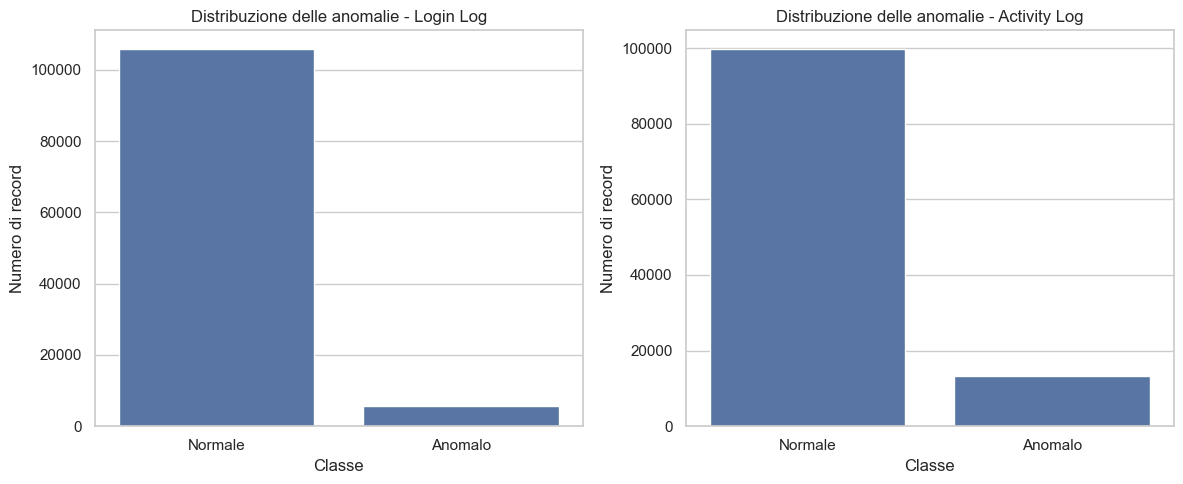

In [14]:
# =========================
# DISTRIBUCIÓN DE ANOMALÍAS
# DISTRIBUZIONE DELLE ANOMALIE
# =========================

# Representamos visualmente cuántos casos normales y anómalos
# existen en Login Log y Activity Log.
# Rappresentiamo visivamente quanti casi normali e anomali
# esistono in Login Log e Activity Log.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras para la variable anomaly del Login Log.
# Mostrará cuántos registros han sido clasificados como normales (0)
# y cuántos como anómalos (1).
# Grafico a barre per la variabile anomaly del Login Log.
# Mostrerà quanti record sono stati classificati come normali (0)
# e quanti come anomali (1).
sns.countplot(data=login_df, x="anomaly", ax=axes[0])
axes[0].set_title("Distribuzione delle anomalie - Login Log")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Numero di record")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Normale", "Anomalo"])

# Gráfico de barras para la variable anomaly del Activity Log.
# También permite comparar visualmente el equilibrio o desequilibrio
# entre casos normales y anómalos.
# Grafico a barre per la variabile anomaly dell'Activity Log.
# Permette anche di confrontare visivamente l'equilibrio o squilibrio
# tra casi normali e anomali.
sns.countplot(data=activity_df, x="anomaly", ax=axes[1])
axes[1].set_title("Distribuzione delle anomalie - Activity Log")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("Numero di record")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Normale", "Anomalo"])

# Ajustamos automáticamente los espacios para que los elementos
# del gráfico no se solapen.
# Regoliamo automaticamente gli spazi per evitare sovrapposizioni.
plt.tight_layout()
plt.show()

Record per utente nel Login Log


user_name
Matteo Nicolosi    49923
Diego Scardino     33515
Emilio Sardo       27900
Name: count, dtype: int64

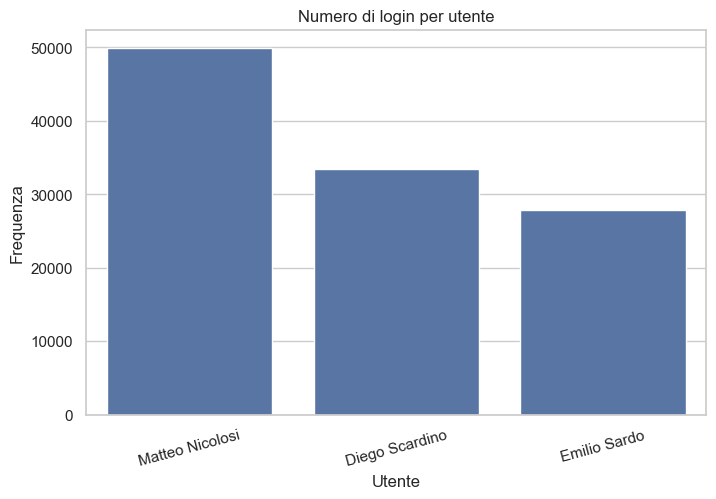

In [15]:
# Analizamos cuántos registros de login tiene cada usuario.
# Esto permite comprobar si todos los usuarios tienen
# suficiente representación en el dataset.
# Analizziamo quanti record di login ha ogni utente.
# Questo permette di verificare se tutti gli utenti hanno
# una rappresentazione sufficiente nel dataset.
print("Record per utente nel Login Log")
display(login_df["user_name"].value_counts())

# Visualización gráfica del número de logins por usuario.
# Visualizzazione grafica del numero di login per utente.
plt.figure(figsize=(8, 5))
sns.countplot(data=login_df, x="user_name")
plt.title("Numero di login per utente")
plt.xlabel("Utente")
plt.ylabel("Frequenza")
plt.xticks(rotation=15)
plt.show()

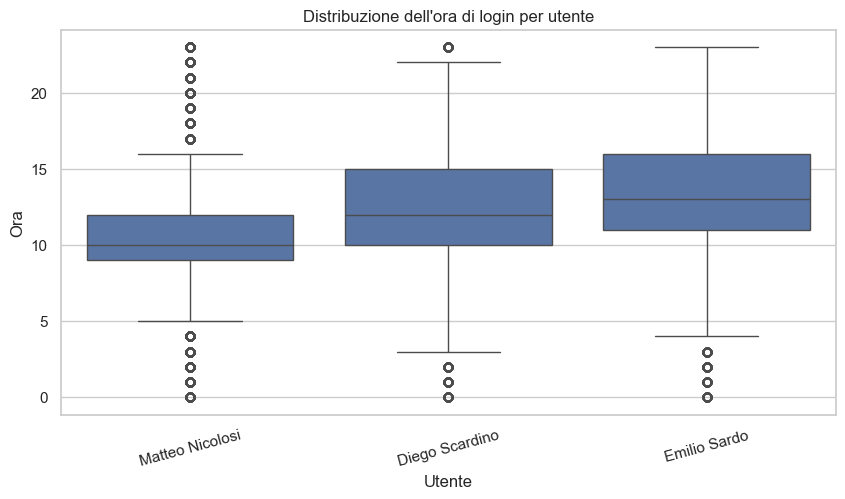

In [16]:
# El boxplot nos permite ver la dispersión de la hora de login
# para cada usuario y detectar visualmente posibles valores atípicos.
# Il boxplot ci permette di vedere la dispersione dell'ora di login
# per ogni utente e di rilevare visivamente possibili valori anomali.
plt.figure(figsize=(10, 5))
sns.boxplot(data=login_df, x="user_name", y="hour")
plt.title("Distribuzione dell'ora di login per utente")
plt.xlabel("Utente")
plt.ylabel("Ora")
plt.xticks(rotation=15)
plt.show()

# Esta gráfica muestra la distribución de la hora de login de cada usuario. En el caso de Matteo, la línea que aparece dentro de la caja indica la mediana,
#  que se sitúa aproximadamente en las 10:00. Esto significa que la mitad de sus accesos se producen antes de esa hora y la otra mitad después.
# La caja azul representa el 50% central de los logins, es decir, el rango donde se concentran la mayoría de accesos habituales. 
# Los bigotes muestran el rango de valores considerados habituales sin contar los valores atípicos.
# Por otro lado, los puntos blancos que aparecen por encima o por debajo representan valores atípicos, es decir, accesos realizados 
# en horas poco frecuentes o alejadas del comportamiento habitual del usuario. En este proyecto, estos puntos pueden interpretarse como posibles casos anómalos.

# Questo grafico mostra la distribuzione dell’ora di login di ciascun utente. Nel caso di Matteo, la linea che appare all’interno 
# della scatola indica la mediana, che si colloca approssimativamente alle 10:00. Ciò significa che metà degli accessi avviene 
# prima di quell’ora e l’altra metà dopo.
# La scatola blu rappresenta il 50% centrale dei login, cioè l’intervallo in cui si concentra la maggior parte degli accessi abituali.
#  I baffi mostrano l’intervallo dei valori considerati abituali, senza tenere conto dei valori atipici.
# D’altra parte, i punti bianchi che appaiono sopra o sotto rappresentano valori atipici, cioè accessi effettuati in orari poco frequenti
# o lontani dal comportamento abituale dell’utente. In questo progetto, questi punti possono essere interpretati come possibili casi anomali.

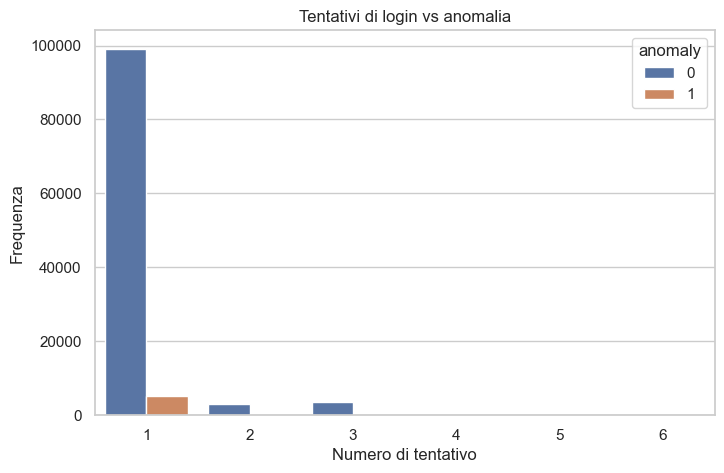

In [17]:
# Observamos cuántos logins se realizan al primer intento,
# segundo intento, etc., y si existe relación con la anomalía.
# Osserviamo quanti login vengono effettuati al primo tentativo,
# al secondo tentativo, ecc., e se esiste una relazione con l'anomalia.
plt.figure(figsize=(8, 5))
sns.countplot(data=login_df, x="attempt", hue="anomaly", order = ['1', '2', '3', '4', '5', '6'])
plt.title("Tentativi di login vs anomalia")
plt.xlabel("Numero di tentativo")
plt.ylabel("Frequenza")
plt.show()

# Lo que aparece en esta grafica es mostrar el numero de intentos que ha necesitado el usuario para poder entrar
# los que aparecen de color azul son casos normales y los marcados en color naranja son anomalias
# Quello che appare in questo grafico è il numero di tentativi di cui l’utente ha avuto bisogno per poter accedere.
# Quelli rappresentati in blu sono casi normali, mentre quelli evidenziati in arancione sono anomalie.

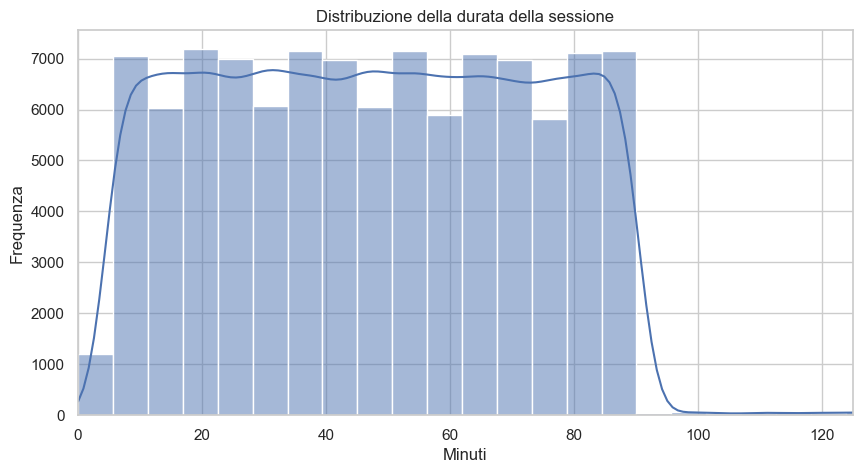

In [18]:
# Histograma de la duración de las sesiones de login.
# Se añade también una curva KDE para visualizar mejor la densidad.
# Istogramma della durata delle sessioni di login.
# Si aggiunge anche una curva KDE per visualizzare meglio la densità.
plt.figure(figsize=(10, 5))
sns.histplot(login_df["session_duration_min"].dropna(), bins=30, kde=True)
plt.title("Distribuzione della durata della sessione")
plt.xlabel("Minuti")
plt.ylabel("Frequenza")
plt.xlim(0, 125)
plt.show()

# Esta gráfica representa la duración de las sesiones abiertas de los usuarios, calculada como la diferencia entre la hora de login y la hora de logout. 
# La curva que aparece superpuesta muestra la densidad de la distribución, es decir, una aproximación suavizada de cómo se reparten las duraciones de las sesiones.
# Questo grafico rappresenta la durata delle sessioni aperte degli utenti, calcolata come differenza tra l’ora di login e l’ora di logout.
# La curva sovrapposta mostra la densità della distribuzione, cioè un’approssimazione smussata di come sono distribuite le durate delle sessioni.

Azioni per utente


user_name        action_name
Diego Scardino   Share           8476
                 Visualize       8452
                 Create          8146
                 Edit            8095
                 Copy             537
                 Delete           179
Emilio Sardo     Share           7276
                 Copy            7133
                 Visualize       7002
                 Edit            6817
                 Create           139
                 Delete           132
Matteo Nicolosi  Copy           16863
                 Visualize      16678
                 Share          16643
                 Edit             170
                 Create           155
                 Delete           144
Name: count, dtype: int64

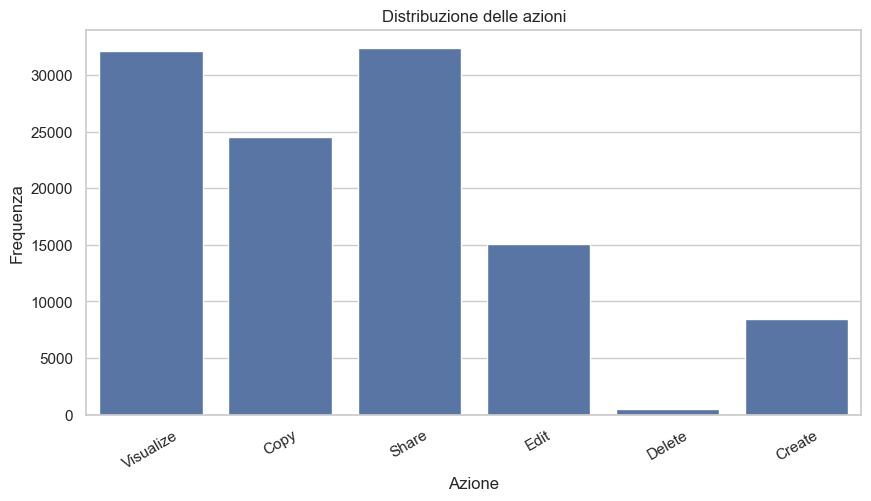

In [19]:
# Mostramos un resumen de cuántas veces realiza cada usuario
# cada tipo de acción.
# Mostriamo un riepilogo di quante volte ogni utente esegue
# ogni tipo di azione.
print("Azioni per utente")
display(activity_df.groupby("user_name")["action_name"].value_counts())

# Gráfico de la distribución global de acciones.
# Grafico della distribuzione globale delle azioni.
plt.figure(figsize=(10, 5))
sns.countplot(data=activity_df, x="action_name")
plt.title("Distribuzione delle azioni")
plt.xlabel("Azione")
plt.ylabel("Frequenza")
plt.xticks(rotation=30)
plt.show()

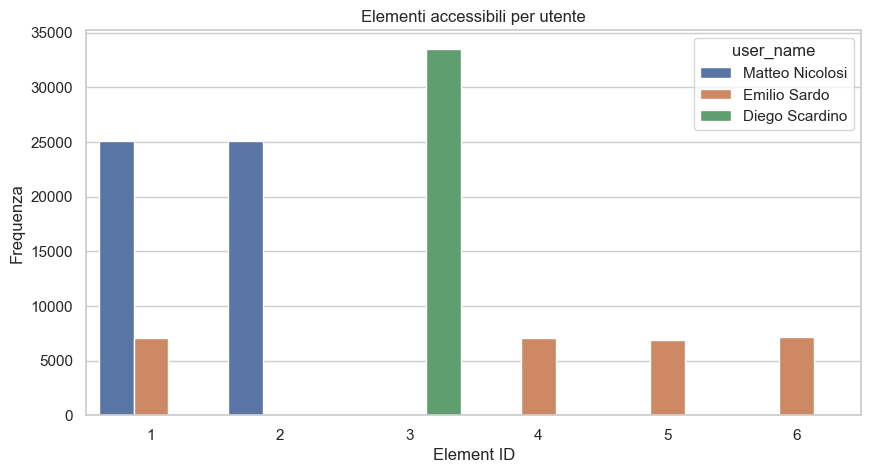

In [20]:
# Este gráfico permite ver qué element_id utiliza cada usuario.
# Es útil para detectar visualmente accesos fuera del conjunto esperado.
# Questo grafico permette di vedere quale element_id utilizza ogni utente.
# È utile per rilevare visivamente accessi al di fuori dell'insieme previsto.
plt.figure(figsize=(10, 5))
sns.countplot(data=activity_df, x="element_id", hue="user_name")
plt.title("Elementi accessibili per utente")
plt.xlabel("Element ID")
plt.ylabel("Frequenza")
plt.show()

# El significado de esta grafica es ver a que elementos entra cada usuario
# Il significato di questo grafico è mostrare a quali elementi accede cias

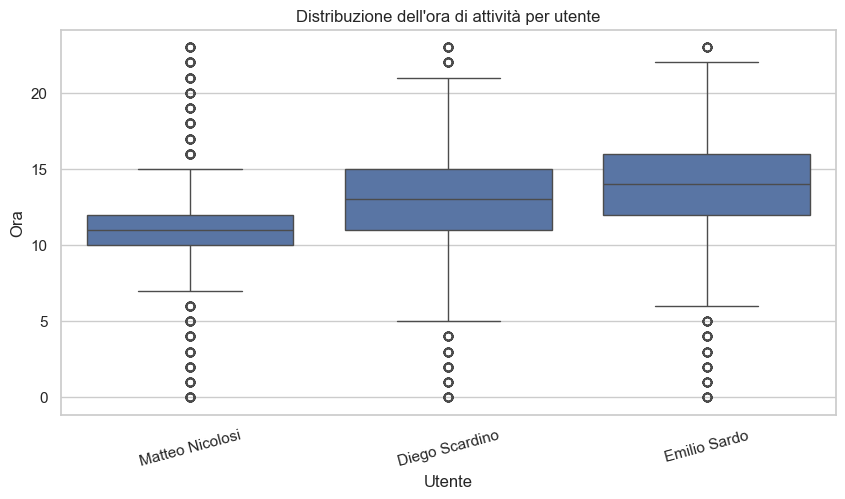

In [21]:
# Al igual que en login, usamos un boxplot para ver
# la distribución horaria de las actividades por usuario.
# Come nel login, utilizziamo un boxplot per vedere
# la distribuzione oraria delle attività per utente.
plt.figure(figsize=(10, 5))
sns.boxplot(data=activity_df, x="user_name", y="hour")
plt.title("Distribuzione dell'ora di attività per utente")
plt.xlabel("Utente")
plt.ylabel("Ora")
plt.xticks(rotation=15)
plt.show()

# Esta gráfica representa la distribución de la hora de actividad de cada usuario. La línea central dentro de cada caja indica la mediana, 
# mientras que la caja azul recoge el 50% central de las actividades. 
# Los bigotes muestran el rango habitual y los puntos blancos representan valores atípicos. 
# Se observa que cada usuario sigue un patrón horario diferente, aunque también aparecen actividades en horas poco frecuentes, 
# que pueden interpretarse como posibles anomalías

# Questo grafico rappresenta la distribuzione dell’ora di attività di ciascun utente. La linea centrale all’interno di ogni scatola indica la mediana, 
# mentre la scatola blu raccoglie il 50% centrale delle attività.
# I baffi mostrano l’intervallo abituale e i punti bianchi rappresentano valori atipici.
# Si osserva che ogni utente segue un pattern orario differente, anche se compaiono anche attività in orari poco frequenti,
#  che possono essere interpretate come possibili anomalie.

In [22]:
# =========================
# PREPARACIÓN MODELO LOGIN
# PREPARAZIONE MODELLO LOGIN
# =========================

# Creamos una copia específica para modelado.
# Creiamo una copia specifica per la modellazione.
login_model_df = login_df.copy()

# Convertimos la variable booleana result a formato entero
# para que el modelo la trate como variable numérica.
# Convertiamo la variabile booleana result in formato intero
# affinché il modello la tratti come variabile numerica.
login_model_df["result"] = login_model_df["result"].astype(int)

# Seleccionamos las variables de entrada del modelo.
# Elegimos variables que describen quién accede, cuándo y cómo.
# Selezioniamo le variabili di input del modello.
# Scegliamo variabili che descrivono chi accede, quando e come.
features_login = ["user_id", "result", "attempt", "hour", "minute", "day_of_week", "session_duration_min"]
target_login = "anomaly"

# X contiene las variables predictoras.
# y contiene la etiqueta objetivo.
# X contiene le variabili predittive.
# y contiene l'etichetta target.
X_login = login_model_df[features_login].copy()
y_login = login_model_df[target_login].copy()

# Si hubiese nulos en la duración, los rellenamos con 0.
# Esto evita errores durante el entrenamiento.
# Se ci fossero valori nulli nella durata, li riempiamo con 0.
# Questo evita errori durante l'addestramento.
X_login["session_duration_min"] = X_login["session_duration_min"].fillna(0)

# Dividimos los datos en entrenamiento y test.
# stratify=y_login ayuda a mantener la proporción de clases.
# Suddividiamo i dati in training e test.
# stratify=y_login aiuta a mantenere la proporzione delle classi.
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_login, y_login, test_size=0.2, random_state=42, stratify=y_login
)

print("Training Login:", Xl_train.shape)
print("Test Login:", Xl_test.shape)


# 89067 registros para entrenar el modelo y 22267 para evaluarlo después, usando en ambos casos 7 variables de entrada.
# 89067 record per addestrare il modello e 22267 per valutarlo successivamente, utilizzando in entrambi i casi 7 variabili di input.

Training Login: (89070, 7)
Test Login: (22268, 7)


In [23]:
# =========================
# MODELO LOGIN
# MODELLO LOGIN
# =========================

# Creamos el clasificador de árbol de decisión.
# max_depth, min_samples_split y min_samples_leaf ayudan
# a evitar sobreajuste y a hacer el árbol más estable.
# Creiamo il classificatore ad albero decisionale.
# max_depth, min_samples_split e min_samples_leaf aiutano
# a evitare l'overfitting e a rendere l'albero più stabile.
login_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Entrenamos el modelo con los datos de entrenamiento.
# Addestriamo il modello con i dati di training.
login_tree.fit(Xl_train, yl_train)

print("Modello di Login addestrato correttamente.")

Modello di Login addestrato correttamente.


In [24]:
# Generamos predicciones sobre el conjunto de test,
# es decir, sobre datos no vistos durante el entrenamiento.
# Generiamo predizioni sul set di test,
# cioè su dati non visti durante l'addestramento.
yl_pred = login_tree.predict(Xl_test)

# Accuracy global del modelo.
# Accuracy globale del modello.
print("Accuracy Login:", accuracy_score(yl_test, yl_pred))

# El classification report ofrece precisión, recall y f1-score.
# Estas métricas son más informativas que la accuracy,
# especialmente si hay desbalance de clases.
# Il classification report fornisce precision, recall e f1-score.
# Queste metriche sono più informative dell'accuracy,
# soprattutto se c'è uno sbilanciamento tra le classi.
print("\nClassification Report - Login")
print(classification_report(yl_test, yl_pred))

Accuracy Login: 0.9973504580564038

Classification Report - Login
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     21154
           1       1.00      0.95      0.97      1114

    accuracy                           1.00     22268
   macro avg       1.00      0.97      0.99     22268
weighted avg       1.00      1.00      1.00     22268



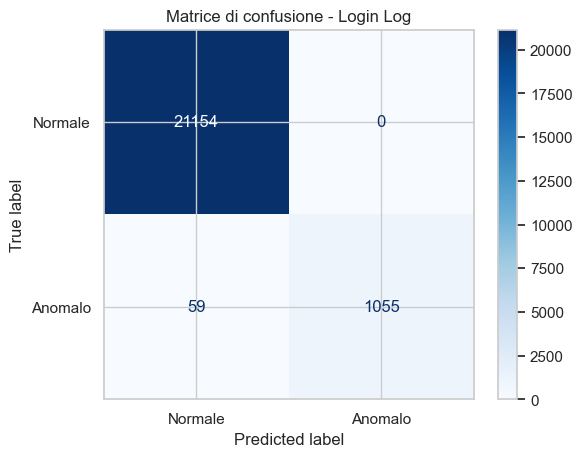

'\nINTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN\n\nEsta matriz se lee tomando como referencia las etiquetas reales en el eje vertical izquierdo (`Normale` y `Anomalie`) y \nlas predicciones del modelo en el eje horizontal inferior.\n\nEsto significa que:\n\n- Hay 19938 casos normales reales, y el modelo ha clasificado correctamente todos ellos como normales.\n- El modelo no ha marcado ningún caso normal como anómalo, por lo que no hay falsos positivos.\n- Hay 2112 casos anómalos reales que el modelo ha detectado correctamente como anómalos.\n- Sin embargo, existen 556 casos anómalos reales que el modelo ha clasificado erróneamente como normales.\n\nEn conclusión, el modelo identifica muy bien los casos normales y detecta una parte importante de las anomalías, \naunque todavía hay algunos comportamientos anómalos que pasan desapercibidos.\nEste rendimiento puede seguir mejorándose con más datos.\n\nINTERPRETAZIONE DELLA MATRICE DI CONFUSIONE\n\nQuesta matrice si legge prendendo come riferim

In [25]:
cm_login = confusion_matrix(yl_test, yl_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_login,
    display_labels=["Normale", "Anomalo"]
)

disp.plot(cmap="Blues")
plt.title("Matrice di confusione - Login Log")
plt.show()

'''
INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN

Esta matriz se lee tomando como referencia las etiquetas reales en el eje vertical izquierdo (`Normale` y `Anomalie`) y 
las predicciones del modelo en el eje horizontal inferior.

Esto significa que:

- Hay 19938 casos normales reales, y el modelo ha clasificado correctamente todos ellos como normales.
- El modelo no ha marcado ningún caso normal como anómalo, por lo que no hay falsos positivos.
- Hay 2112 casos anómalos reales que el modelo ha detectado correctamente como anómalos.
- Sin embargo, existen 556 casos anómalos reales que el modelo ha clasificado erróneamente como normales.

En conclusión, el modelo identifica muy bien los casos normales y detecta una parte importante de las anomalías, 
aunque todavía hay algunos comportamientos anómalos que pasan desapercibidos.
Este rendimiento puede seguir mejorándose con más datos.

INTERPRETAZIONE DELLA MATRICE DI CONFUSIONE

Questa matrice si legge prendendo come riferimento le etichette reali sull’asse verticale sinistro (`Normale` e `Anomalie`) e le predizioni del modello sull’asse orizzontale inferiore.

Questo significa che:

- Ci sono 19938 casi normali reali e il modello li ha classificati correttamente tutti come normali.
- Il modello non ha contrassegnato nessun caso normale come anomalo, quindi non ci sono falsi positivi.
- Ci sono 2112 casi anomali reali che il modello ha rilevato correttamente come anomali.
- Tuttavia, esistono 556 casi anomali reali che il modello ha classificato erroneamente come normali.

In conclusione, il modello identifica molto bene i casi normali e rileva una parte importante delle anomalie, anche se esistono ancora alcuni comportamenti anomali che passano inosservati.
Queste prestazioni possono continuare a migliorare con una maggiore quantità di dati.
'''

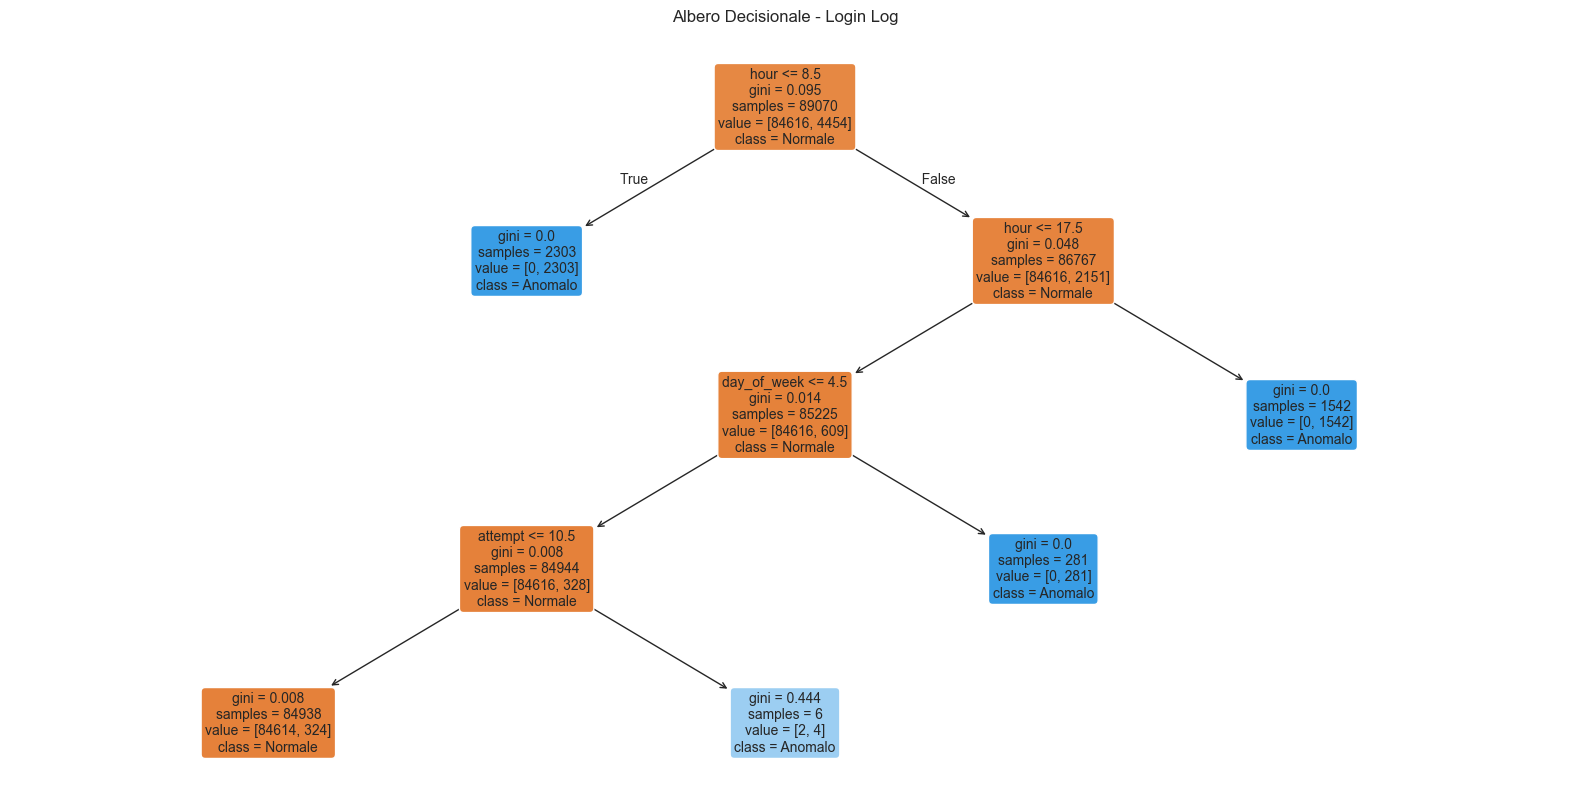

In [26]:
# Dibujamos el árbol completo para entender
# qué decisiones toma el modelo y en qué variables se apoya.
# Disegniamo l'albero completo per capire
# quali decisioni prende il modello e su quali variabili si basa.
plt.figure(figsize=(20, 10))
plot_tree(
    login_tree,
    feature_names=features_login,
    class_names=["Normale", "Anomalo"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Albero Decisionale - Login Log")
plt.show()

# El árbol de decisión del Login Log muestra que la variable más relevante para clasificar un acceso como normal o anómalo es la hora del login.
# El primer criterio de separación se sitúa en torno a las 08:30, lo que indica que los accesos realizados antes de esa hora son considerados claramente anómalos. 
# Posteriormente, el modelo vuelve a dividir por hora y por día de la semana, detectando también como anómalos los accesos realizados 
# después de las 17:30 o durante el fin de semana. Esto confirma que el modelo ha aprendido correctamente el patrón horario definido en las reglas de negocio.
# gini --> es una medida de pureza, cuanto mas cercano este al 0 es mas puro y eficiente.
# samples --> son la de casos que han entrado por este nodo
# value --> indica cuántos casos de cada clase hay en ese nodo; en este problema el primer valor corresponde a los casos normales y el segundo a los anómalos.
# class --> indica la clase final que el árbol asigna a ese nodo, es decir, la categoría mayoritaria entre los registros que han llegado hasta él.
# True --> significa que la condición del nodo se cumple y por tanto el árbol sigue la rama izquierda.
# False --> significa que la condición del nodo no se cumple y por tanto el árbol sigue la rama derecha.
# color naranja --> representa nodos clasificados principalmente como normales.
# color azul --> representa nodos clasificados principalmente como anómalos.

# L’albero decisionale del Login Log mostra che la variabile più rilevante per classificare un accesso come normale o anomalo è l’ora del login.
# Il primo criterio di separazione si colloca intorno alle 08:30, il che indica che gli accessi effettuati prima di quell’ora sono considerati chiaramente anomali.
# Successivamente, il modello continua a suddividere per ora e per giorno della settimana, rilevando come anomali anche gli accessi effettuati
# dopo le 17:30 o durante il fine settimana. Questo conferma che il modello ha appreso correttamente il pattern orario definito nelle regole di business.
# gini --> è una misura di purezza; quanto più è vicino a 0, tanto più il nodo è puro ed efficiente.
# samples --> è il numero di casi che sono arrivati a quel nodo.
# value --> indica quanti casi di ciascuna classe sono presenti in quel nodo; in questo problema il primo valore corrisponde ai casi normali e il secondo a quelli anomali.
# class --> indica la classe finale che l’albero assegna a quel nodo, cioè la categoria maggioritaria tra i record che vi sono arrivati.
# True --> significa che la condizione del nodo è soddisfatta e quindi l’albero segue il ramo sinistro.
# False --> significa che la condizione del nodo non è soddisfatta e quindi l’albero segue il ramo destro.
# colore arancione --> rappresenta nodi classificati principalmente come normali.
# colore blu --> rappresenta nodi classificati principalmente come anomali.

In [27]:
# =========================
# PREPARACIÓN MODELO ACTIVITY
# PREPARAZIONE MODELLO ACTIVITY
# =========================

# Copia del dataset ya enriquecido y etiquetado.
# Copia del dataset già arricchito ed etichettato.
activity_model_df = activity_df.copy()

# Selección de variables predictoras del modelo de actividad.
# Aquí usamos información sobre usuario, elemento, entidad, acción y tiempo.
# Selezione delle variabili predittive del modello di attività.
# Qui utilizziamo informazioni su utente, elemento, entità, azione e tempo.
features_activity = ["user_id", "element_id", "entity_id", "action_id", "hour", "minute", "day_of_week"]
target_activity = "anomaly"

# Variables de entrada y variable objetivo.
# Variabili di input e variabile target.
X_activity = activity_model_df[features_activity].copy()
y_activity = activity_model_df[target_activity].copy()

# División en entrenamiento y test.
# Suddivisione in training e test.
Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_activity, y_activity, test_size=0.2, random_state=42, stratify=y_activity
)

print("Training Activity:", Xa_train.shape)
print("Test Activity:", Xa_test.shape)

Training Activity: (90429, 7)
Test Activity: (22608, 7)


In [28]:
# =========================
# MODELO ACTIVITY
# MODELLO ACTIVITY
# =========================

# Creamos el árbol de decisión para el dataset de actividad.
# En este caso se permite una profundidad algo mayor
# porque el problema tiene más variables y combinaciones.
# Creiamo l'albero decisionale per il dataset di attività.
# In questo caso si consente una profondità leggermente maggiore
# perché il problema ha più variabili e combinazioni.
activity_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Entrenamiento del modelo.
# Addestramento del modello.
activity_tree.fit(Xa_train, ya_train)

print("Modello di Activity addestrato correttamente.")

Modello di Activity addestrato correttamente.


In [29]:
# Predicción sobre el conjunto de prueba del Activity Log.
# Predizione sul set di test dell'Activity Log.
ya_pred = activity_tree.predict(Xa_test)

# Exactitud global.
# Accuratezza globale.
print("Accuracy Activity:", accuracy_score(ya_test, ya_pred))

# Métricas detalladas por clase.
# Metriche dettagliate per classe.
print("\nClassification Report - Activity")
print(classification_report(ya_test, ya_pred))

Accuracy Activity: 0.9757607926397736

Classification Report - Activity
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     19939
           1       1.00      0.79      0.89      2669

    accuracy                           0.98     22608
   macro avg       0.99      0.90      0.94     22608
weighted avg       0.98      0.98      0.97     22608



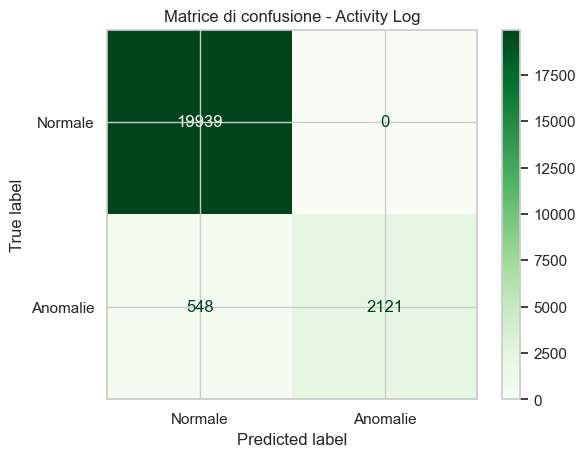

'\nEsta matriz se lee tomando como referencia las etiquetas reales en el eje vertical izquierdo (`Normale` y `Anomalie`) \ny las predicciones del modelo en el eje horizontal inferior.\n\nEsto significa que:\n\n- Hay 19938 casos normales reales, y el modelo ha clasificado correctamente todos ellos como normales.\n- El modelo no ha marcado ningún caso normal como anómalo, por lo que no hay falsos positivos.\n- Hay 2112 casos anómalos reales que el modelo ha detectado correctamente como anómalos.\n- Sin embargo, existen 556 casos anómalos reales que el modelo ha clasificado erróneamente como normales.\n\nEn conclusión, el modelo identifica muy bien los casos normales y detecta una parte importante de las anomalías, aunque todavía \nhay algunos comportamientos anómalos que pasan desapercibidos. Este rendimiento puede seguir mejorándose con más datos.\n\n\nQuesta matrice si legge prendendo come riferimento le etichette reali sull’asse verticale sinistro (`Normale` e `Anomalie`)\n e le predi

In [30]:
# Matriz de confusión del modelo de actividad.
# Matrice di confusione del modello di attività.
cm_activity = confusion_matrix(ya_test, ya_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_activity,
    display_labels=["Normale", "Anomalie"]
)

disp.plot(cmap="Greens", values_format = 'd')
plt.title("Matrice di confusione - Activity Log")
plt.show()

'''
Esta matriz se lee tomando como referencia las etiquetas reales en el eje vertical izquierdo (`Normale` y `Anomalie`) 
y las predicciones del modelo en el eje horizontal inferior.

Esto significa que:

- Hay 19938 casos normales reales, y el modelo ha clasificado correctamente todos ellos como normales.
- El modelo no ha marcado ningún caso normal como anómalo, por lo que no hay falsos positivos.
- Hay 2112 casos anómalos reales que el modelo ha detectado correctamente como anómalos.
- Sin embargo, existen 556 casos anómalos reales que el modelo ha clasificado erróneamente como normales.

En conclusión, el modelo identifica muy bien los casos normales y detecta una parte importante de las anomalías, aunque todavía 
hay algunos comportamientos anómalos que pasan desapercibidos. Este rendimiento puede seguir mejorándose con más datos.


Questa matrice si legge prendendo come riferimento le etichette reali sull’asse verticale sinistro (`Normale` e `Anomalie`)
 e le predizioni del modello sull’asse orizzontale inferiore.

Questo significa che:

- Ci sono 19938 casi normali reali e il modello li ha classificati correttamente tutti come normali.
- Il modello non ha contrassegnato nessun caso normale come anomalo, quindi non ci sono falsi positivi.
- Ci sono 2112 casi anomali reali che il modello ha rilevato correttamente come anomali.
- Tuttavia, esistono 556 casi anomali reali che il modello ha classificato erroneamente come normali.

In conclusione, il modello identifica molto bene i casi normali e rileva una parte importante delle anomalie, anche se 
esistono ancora alcuni comportamenti anomali che passano inosservati. Queste prestazioni possono continuare a migliorare con una maggiore quantità di dati.
'''

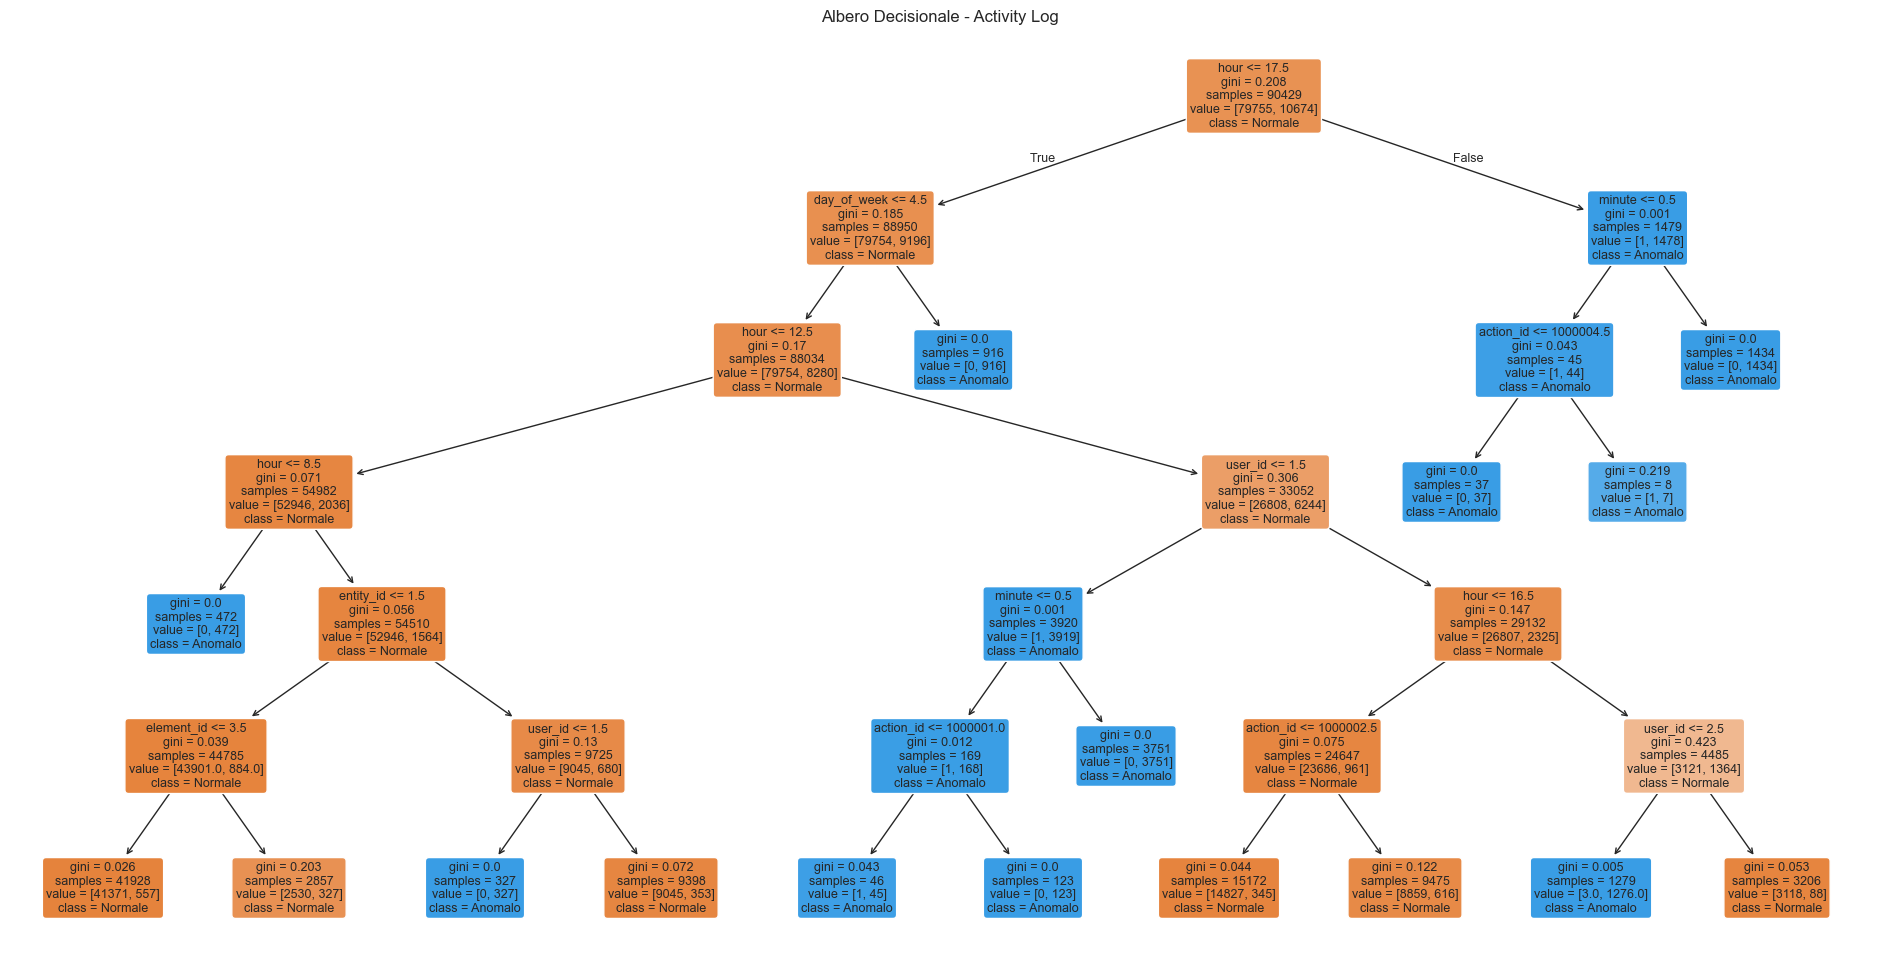

In [31]:
# Representación gráfica del árbol de actividad.
# Muy útil en la defensa del proyecto porque permite
# mostrar qué criterios separan actividad normal y anómala.
# Rappresentazione grafica dell'albero di attività.
# Molto utile nella presentazione del progetto perché permette
# di mostrare quali criteri separano l'attività normale da quella anomala.
plt.figure(figsize=(24, 12))
plot_tree(
    activity_tree,
    feature_names=features_activity,
    class_names=["Normale", "Anomalo"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Albero Decisionale - Activity Log")
plt.show()

In [32]:
# Aplicamos ambos modelos sobre todos los registros para comparar
# la etiqueta real generada por reglas con la predicción del árbol.
# Applichiamo entrambi i modelli su tutti i record per confrontare
# l'etichetta reale generata dalle regole con la previsione dell'albero.
login_df["predicted_anomaly"] = login_tree.predict(X_login)
activity_df["predicted_anomaly"] = activity_tree.predict(X_activity)

# Mostramos una comparación entre la anomalía real y la predicha en el dataset de login.
# Mostriamo un confronto tra l'anomalia reale e quella predetta nel dataset di login.
print("LOGIN - confronto reale vs previsione")
display(login_df[["login_log_id", "user_id", "user_name", "logged_at", "anomaly", "predicted_anomaly"]].head(20))

# Hacemos lo mismo con el dataset de actividad.
# Facciamo lo stesso con il dataset di attività.
print("\nACTIVITY - confronto reale vs previsione")
display(activity_df[["activity_log_id", "user_id", "user_name", "element_id", "action_id", "logged_at", "anomaly", "predicted_anomaly"]].head(20))

LOGIN - confronto reale vs previsione


,login_log_id,user_id,user_name,logged_at,anomaly,predicted_anomaly
0,3,1,Matteo Nicolosi,2026-01-01 09:06:55.942861,0,0
1,4,2,Diego Scardino,2026-01-01 12:23:22.204540,0,0
2,6,3,Emilio Sardo,2026-01-01 17:40:17.890470,0,0
3,9,1,Matteo Nicolosi,2026-01-02 10:10:32.177307,0,0
4,10,2,Diego Scardino,2026-01-02 12:47:29.386148,0,0
5,12,3,Emilio Sardo,2026-01-02 16:12:38.083466,0,0
6,13,1,Matteo Nicolosi,2026-01-05 09:20:03.990672,0,0
7,16,2,Diego Scardino,2026-01-05 13:49:11.388822,0,0
8,17,3,Emilio Sardo,2026-01-05 16:22:10.634313,0,0
9,18,1,Matteo Nicolosi,2026-01-06 09:20:18.448836,0,0



ACTIVITY - confronto reale vs previsione


,activity_log_id,user_id,user_name,element_id,action_id,logged_at,anomaly,predicted_anomaly
0,1,1,Matteo Nicolosi,2,1000000,2026-01-01 10:31:04.217659,0,0
1,2,2,Diego Scardino,3,1000004,2026-01-01 14:37:47.860663,1,0
2,3,3,Emilio Sardo,6,1000005,2026-01-01 17:44:36.455155,0,0
3,4,1,Matteo Nicolosi,1,1000000,2026-01-02 10:14:36.855413,0,0
4,5,1,Matteo Nicolosi,2,1000000,2026-01-02 10:15:31.904461,0,0
5,6,1,Matteo Nicolosi,2,1000004,2026-01-02 10:34:10.221465,0,0
6,7,1,Matteo Nicolosi,1,1000005,2026-01-02 10:45:38.782043,0,0
7,8,1,Matteo Nicolosi,1,1000004,2026-01-02 10:50:27.144459,0,0
8,9,1,Matteo Nicolosi,2,1000005,2026-01-02 11:00:25.523449,0,0
9,10,1,Matteo Nicolosi,1,1000005,2026-01-02 11:17:42.260470,0,0


In [33]:
# Filtramos únicamente los registros que el modelo clasifica como anómalos.
# Filtriamo unicamente i record che il modello classifica come anomali.
login_anomalies = login_df[login_df["predicted_anomaly"] == 1].copy()

# Mostramos los casos anómalos detectados por el modelo junto con
# la anomalía real y el motivo asociado según las reglas de negocio.
# Mostriamo i casi anomali rilevati dal modello insieme
# all'anomalia reale e al motivo associato secondo le regole di business.
print("Casi anomali rilevati nel Login:")
display(
    login_anomalies[
        [
            "login_log_id",
            "user_id",
            "user_name",
            "result",
            "attempt",
            "logged_at",
            "logout_at",
            "hour",
            "anomaly",
            "anomaly_reason",
            "predicted_anomaly"
        ]
    ].sort_values("logged_at")
)


Casi anomali rilevati nel Login:


,login_log_id,user_id,user_name,result,attempt,logged_at,logout_at,hour,anomaly,anomaly_reason,predicted_anomaly
98845,230528,3,Emilio Sardo,True,1,2025-12-15 02:37:50.000000,2025-12-15 03:49:50.000000,2,1,Anomalia: stai tentando di accedere molto fuor...,1
76239,207922,1,Matteo Nicolosi,True,1,2025-12-15 03:32:08.000000,2025-12-15 04:43:08.000000,3,1,Anomalia: stai tentando di accedere molto fuor...,1
102184,233867,3,Emilio Sardo,True,1,2025-12-15 04:46:25.000000,2025-12-15 05:41:25.000000,4,1,Anomalia: stai tentando di accedere molto fuor...,1
84282,215965,2,Diego Scardino,True,1,2025-12-15 05:15:41.000000,2025-12-15 06:06:41.000000,5,1,Anomalia: stai tentando di accedere molto fuor...,1
19549,151232,1,Matteo Nicolosi,False,3,2025-12-15 07:08:37.000000,NaT,7,1,Anomalia: stai tentando di accedere molto fuor...,1
...,...,...,...,...,...,...,...,...,...,...,...
111335,243018,1,Matteo Nicolosi,True,20,2026-04-14 16:40:47.301205,2026-04-14 16:41:08.728080,16,1,Anomalia: stai tentando di accedere molto fuor...,1
31044,162727,2,Diego Scardino,True,1,2026-04-14 18:47:26.000000,2026-04-14 19:35:26.000000,18,1,Anomalia: stai tentando di accedere molto fuor...,1
12478,144161,3,Emilio Sardo,True,1,2026-04-14 21:40:40.000000,2026-04-14 22:36:40.000000,21,1,Anomalia: stai tentando di accedere molto fuor...,1
111336,243019,1,Matteo Nicolosi,True,21,2026-04-15 10:26:24.969903,2026-04-15 10:26:52.303319,10,0,Normal,1


In [34]:
# Filtramos únicamente las actividades que el modelo clasifica como anómalas.
# Filtriamo unicamente le attività che il modello classifica come anomale.
activity_anomalies = activity_df[activity_df["predicted_anomaly"] == 1].copy()

# Mostramos los casos anómalos detectados por el modelo junto con
# la anomalía real y el motivo textual asociado según las reglas.
# Mostriamo i casi anomali rilevati dal modello insieme
# all'anomalia reale e al motivo testuale associato secondo le regole.
print("Casi anomali rilevati in Activity:")
display(
    activity_anomalies[
        [
            "activity_log_id",
            "user_id",
            "user_name",
            "element_id",
            "entity_id",
            "action_id",
            "action_name",
            "logged_at",
            "hour",
            "anomaly",
            "anomaly_reason",
            "predicted_anomaly"
        ]
    ].sort_values("logged_at")
)

Casi anomali rilevati in Activity:


,activity_log_id,user_id,user_name,element_id,entity_id,action_id,action_name,logged_at,hour,anomaly,anomaly_reason,predicted_anomaly
101011,231012,1,Matteo Nicolosi,1,1,1000005,Share,2025-12-15 03:00:43,3,1,Anomalia: attività eseguita molto fuori dall'o...,1
110327,240328,1,Matteo Nicolosi,4,1,1000000,Visualize,2025-12-15 04:30:16,4,1,Anomalia: attività eseguita molto fuori dall'o...,1
40836,170837,1,Matteo Nicolosi,1,1,1000004,Copy,2025-12-15 05:48:25,5,1,Anomalia: attività eseguita molto fuori dall'o...,1
101438,231439,1,Matteo Nicolosi,1,3,1000005,Share,2025-12-15 09:57:53,9,1,Anomalia: stai accedendo a un'entità non conse...,1
44726,174727,1,Matteo Nicolosi,2,3,1000004,Copy,2025-12-15 11:29:42,11,1,Anomalia: stai accedendo a un'entità non conse...,1
...,...,...,...,...,...,...,...,...,...,...,...,...
43658,173659,1,Matteo Nicolosi,1,1,1000000,Visualize,2026-04-14 18:36:30,18,1,Anomalia: attività eseguita molto fuori dall'o...,1
32785,162786,3,Emilio Sardo,1,3,1000005,Share,2026-04-14 18:51:58,18,1,Anomalia: attività eseguita molto fuori dall'o...,1
38518,168519,2,Diego Scardino,3,1,1000000,Visualize,2026-04-14 20:23:37,20,1,Anomalia: attività eseguita molto fuori dall'o...,1
67501,197502,3,Emilio Sardo,1,3,1000004,Copy,2026-04-14 20:27:56,20,1,Anomalia: attività eseguita molto fuori dall'o...,1


In [35]:
# Definimos una función para probar manualmente nuevos casos de login
# y comparar la predicción del modelo con la evaluación por reglas.
# Definiamo una funzione per testare manualmente nuovi casi di login
# e confrontare la previsione del modello con la valutazione basata sulle regole.
def predict_login_anomaly(user_id, result, attempt, logged_at, logout_at):
    # Convertimos las fechas introducidas a formato datetime.
    # Convertiamo le date inserite in formato datetime.
    logged_at = pd.to_datetime(logged_at)
    logout_at = pd.to_datetime(logout_at)

    # Calculamos la duración de la sesión en minutos.
    # Calcoliamo la durata della sessione in minuti.
    session_duration_min = (logout_at - logged_at).total_seconds() / 60

    # Construimos un DataFrame con la misma estructura de variables
    # que espera el modelo de login.
    # Costruiamo un DataFrame con la stessa struttura di variabili
    # che il modello di login si aspetta.
    row = pd.DataFrame([{
        "user_id": user_id,
        "result": int(result),
        "attempt": attempt,
        "hour": logged_at.hour,
        "minute": logged_at.minute,
        "day_of_week": logged_at.dayofweek,
        "session_duration_min": session_duration_min
    }])

    # Predicción del árbol y probabilidades asociadas.
    # Previsione dell'albero e probabilità associate.
    pred = login_tree.predict(row)[0]
    prob = login_tree.predict_proba(row)[0]

    # Evaluación del mismo caso según las reglas de negocio.
    # Valutazione dello stesso caso secondo le regole di business.
    rule_messages = rules.evaluate_login_anomaly(
        user_id=user_id,
        dt=logged_at.to_pydatetime()
    )

    # Mostramos el resultado del modelo.
    # Mostriamo il risultato del modello.
    print("=== RESULTADO DEL MODELO ===")
    print("Previsión:", "ANÓMALO" if pred == 1 else "NORMAL")
    print("Probabilidades [Normal, Anómalo]:", prob)

    # Mostramos también el resultado según las reglas.
    # Mostriamo anche il risultato secondo le regole.
    print("\n=== RESULTADO SEGÚN REGLAS ===")
    if rule_messages:
        print("El caso sería considerado ANÓMALO por reglas.")
        for msg in rule_messages:
            print("-", msg)
    else:
        print("El caso sería considerado NORMAL por reglas.")

    # Devolvemos también la predicción por si quieres reutilizarla después.
    # Restituiamo anche la previsione nel caso tu voglia riutilizzarla dopo.
    return pred, prob, rule_messages


# Ejemplo de uso:
# Esempio di utilizzo:
predict_login_anomaly(
    user_id=1,
    result=True,
    attempt=2,
    logged_at="2026-01-15 16:30:00",
    logout_at="2026-01-15 17:00:00"
)

=== RESULTADO DEL MODELO ===
Previsión: NORMAL
Probabilidades [Normal, Anómalo]: [0.99618545 0.00381455]

=== RESULTADO SEGÚN REGLAS ===
El caso sería considerado ANÓMALO por reglas.
- Anomalia: stai tentando di accedere molto fuori dal tuo orario di lavoro.


(np.int64(0),
 array([0.99618545, 0.00381455]),
 ['Anomalia: stai tentando di accedere molto fuori dal tuo orario di lavoro.'])

In [36]:
# Función para probar manualmente nuevos eventos del Activity Log
# y comparar la predicción del modelo con la evaluación por reglas.
# Funzione per testare manualmente nuovi eventi dell'Activity Log
# e confrontare la previsione del modello con la valutazione basata sulle regole.
def predict_activity_anomaly(user_id, element_id, entity_id, action_id, logged_at):
    # Convertimos la fecha introducida a formato datetime.
    # Convertiamo la data inserita in formato datetime.
    logged_at = pd.to_datetime(logged_at)

    # Construimos un DataFrame con la misma estructura de variables
    # que espera el modelo de actividad.
    # Costruiamo un DataFrame con la stessa struttura di variabili
    # che il modello di attività si aspetta.
    row = pd.DataFrame([{
        "user_id": user_id,
        "element_id": element_id,
        "entity_id": entity_id,
        "action_id": action_id,
        "hour": logged_at.hour,
        "minute": logged_at.minute,
        "day_of_week": logged_at.dayofweek
    }])

    # Predicción del árbol y probabilidades asociadas.
    # Previsione dell'albero e probabilità associate.
    pred = activity_tree.predict(row)[0]
    prob = activity_tree.predict_proba(row)[0]

    # Evaluación del mismo caso según las reglas de negocio.
    # Valutazione dello stesso caso secondo le regole di business.
    rule_messages = rules.evaluate_activity_anomaly(
        user_id=user_id,
        element_id=element_id,
        entity_id=entity_id,
        action_id=action_id,
        dt=logged_at.to_pydatetime()
    )

    # Mostramos el resultado del modelo.
    # Mostriamo il risultato del modello.
    print("=== RESULTADO DEL MODELO ===")
    print("Previsión:", "ANÓMALO" if pred == 1 else "NORMAL")
    print("Probabilidades [Normal, Anómalo]:", prob)

    # Mostramos también el resultado según las reglas.
    # Mostriamo anche il risultato secondo le regole.
    print("\n=== RESULTADO SEGÚN REGLAS ===")
    if rule_messages:
        print("El caso sería considerado ANÓMALO por reglas.")
        for msg in rule_messages:
            print("-", msg)
    else:
        print("El caso sería considerado NORMAL por reglas.")

    # Devolvemos la predicción por si quieres reutilizarla después.
    # Restituiamo la previsione nel caso tu voglia riutilizzarla dopo.
    return pred, prob, rule_messages


# Ejemplo de uso:
# Esempio di utilizzo:
predict_activity_anomaly(
    user_id=2,
    element_id=1,
    entity_id=1,
    action_id=1000005,
    logged_at="2026-01-20 13:15:00"
)

=== RESULTADO DEL MODELO ===
Previsión: NORMAL
Probabilidades [Normal, Anómalo]: [0.93498681 0.06501319]

=== RESULTADO SEGÚN REGLAS ===
El caso sería considerado ANÓMALO por reglas.
- Anomalia: stai accedendo a un elemento che non ti è consentito.


(np.int64(0),
 array([0.93498681, 0.06501319]),
 ['Anomalia: stai accedendo a un elemento che non ti è consentito.'])

In [37]:
# =========================
# ENTRENAMIENTO DEL MODELO RANDOM FOREST
# ADDESTRAMENTO DEL MODELLO RANDOM FOREST
# =========================

# Creamos el modelo Random Forest.
# Parámetros elegidos:
# - n_estimators: número de árboles que formarán el bosque.
# - max_depth: profundidad máxima de cada árbol, para evitar sobreajuste excesivo.
# - min_samples_split: mínimo de muestras para dividir un nodo.
# - min_samples_leaf: mínimo de muestras que debe tener una hoja.
# - random_state: garantiza reproducibilidad.
# - n_jobs=-1: usa todos los núcleos del procesador disponibles.

# Creiamo il modello Random Forest.
# Parametri scelti:
# - n_estimators: numero di alberi che formeranno la foresta.
# - max_depth: profondità massima di ogni albero, per evitare un overfitting eccessivo.
# - min_samples_split: numero minimo di campioni per dividere un nodo.
# - min_samples_leaf: numero minimo di campioni che deve avere una foglia.
# - random_state: garantisce la riproducibilità.
# - n_jobs=-1: utilizza tutti i core del processore disponibili.

rf_activity = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Entrenamos el modelo con los datos de entrenamiento.
# Addestriamo il modello con i dati di training.
rf_activity.fit(Xa_train, ya_train)

# Mostramos confirmación y accuracy en train/test
# para tener una primera visión de si hay sobreajuste.

# Mostriamo una conferma e l'accuracy su train/test
# per avere una prima idea dell'eventuale presenza di overfitting.
print("Modello Random Forest addestrato correttamente.")
print("Accuracy train:", rf_activity.score(Xa_train, ya_train))
print("Accuracy test:", rf_activity.score(Xa_test, ya_test))

Modello Random Forest addestrato correttamente.
Accuracy train: 0.9775514492032423
Accuracy test: 0.9780166312809625


In [38]:
# =========================
# EVALUACIÓN DEL MODELO RANDOM FOREST
# VALUTAZIONE DEL MODELLO RANDOM FOREST
# =========================

# Generamos predicciones sobre el conjunto de prueba.
# Generiamo predizioni sul set di test.
ya_pred_rf = rf_activity.predict(Xa_test)

# Accuracy global del modelo.
# Accuracy globale del modello.
print("Accuracy Random Forest:", accuracy_score(ya_test, ya_pred_rf))

# El classification report muestra métricas más completas:
# - precision
# - recall
# - f1-score
# Esto es especialmente importante en problemas de detección de anomalías.

# Il classification report mostra metriche più complete:
# - precision
# - recall
# - f1-score
# Questo è particolarmente importante nei problemi di rilevamento delle anomalie.
print("\nClassification Report - Random Forest (Activity Log)")
print(
    classification_report(
        ya_test,
        ya_pred_rf,
        labels=[0, 1],
        target_names=["Normale", "Anomalo"],
        zero_division=0
    )
)

# El modelo Random Forest alcanza una accuracy del 97.69% sobre el conjunto de prueba del Activity Log. 
# En la clase normal obtiene resultados excelentes, con un recall de 1.00 y una precisión de 0.97. 
# En la clase anómala, la precisión alcanza 1.00, lo que indica que todas las actividades marcadas como anómalas por el modelo eran realmente anómalas. 
# Sin embargo, el recall de la clase anómala es 0.80, lo que implica que una parte de las anomalías reales no ha sido detectada. 
# En conjunto, el modelo presenta un comportamiento sólido y conservador, priorizando la ausencia de falsas alarmas frente a la detección total de anomalías.

Accuracy Random Forest: 0.9780166312809625

Classification Report - Random Forest (Activity Log)
              precision    recall  f1-score   support

     Normale       0.98      1.00      0.99     19939
     Anomalo       1.00      0.81      0.90      2669

    accuracy                           0.98     22608
   macro avg       0.99      0.91      0.94     22608
weighted avg       0.98      0.98      0.98     22608



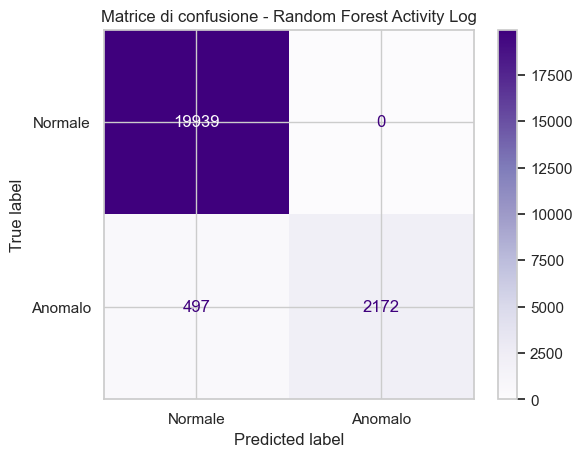

In [39]:
# =========================
# MATRIZ DE CONFUSIÓN - RANDOM FOREST
# MATRICE DI CONFUSIONE - RANDOM FOREST
# =========================

# Calculamos la matriz de confusión forzando las clases [0, 1]
# para que siempre se represente correctamente.
# Calcoliamo la matrice di confusione forzando le classi [0, 1]
# affinché venga sempre rappresentata correttamente.
cm_rf = confusion_matrix(ya_test, ya_pred_rf, labels=[0, 1])

# Mostramos la matriz con etiquetas claras.
# Mostriamo la matrice con etichette chiare.
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Normale", "Anomalo"]
)

disp.plot(cmap="Purples", values_format = 'd')
plt.title("Matrice di confusione - Random Forest Activity Log")
plt.show()

# La matriz de confusión del modelo Random Forest para el Activity Log muestra que el sistema clasifica correctamente 19938 casos normales y 2146 casos anómalos. 
# Además, no genera falsos positivos, ya que ningún caso normal ha sido marcado como anómalo. 
# Sin embargo, 522 actividades anómalas reales han sido clasificadas como normales, lo que indica que todavía hay una parte de las anomalías que no logra detectar.
# En conjunto, el modelo presenta un comportamiento sólido, muy fiable para confirmar anomalías y especialmente eficaz en la clasificación de casos normales.

# La matrice di confusione del modello Random Forest per l’Activity Log mostra che il sistema classifica correttamente 19938 casi normali e 2146 casi anomali.
# Inoltre, non genera falsi positivi, poiché nessun caso normale è stato contrassegnato come anomalo.
# Tuttavia, 522 attività anomale reali sono state classificate come normali, il che indica che esiste ancora una parte delle anomalie che il modello non riesce a rilevare.
# Nel complesso, il modello presenta un comportamento solido, molto affidabile nel confermare le anomalie ed è particolarmente efficace nella classificazione dei casi normali.

In [40]:
# =========================
# IMPORTANCIA DE VARIABLES - RANDOM FOREST
# IMPORTANZA DELLE VARIABILI - RANDOM FOREST
# =========================

# Extraemos la importancia de cada variable utilizada por el modelo.
# Estraiamo l'importanza di ogni variabile utilizzata dal modello.
rf_importance_df = pd.DataFrame({
    "feature": X_activity.columns,
    "importance": rf_activity.feature_importances_
}).sort_values("importance", ascending=False)

# Mostramos la tabla ordenada de mayor a menor importancia.
# Mostriamo la tabella ordinata dalla variabile più importante alla meno importante.
display(rf_importance_df)

,feature,importance
4,hour,0.576075
0,user_id,0.134234
6,day_of_week,0.111939
1,element_id,0.081284
2,entity_id,0.045056
3,action_id,0.032298
5,minute,0.019114


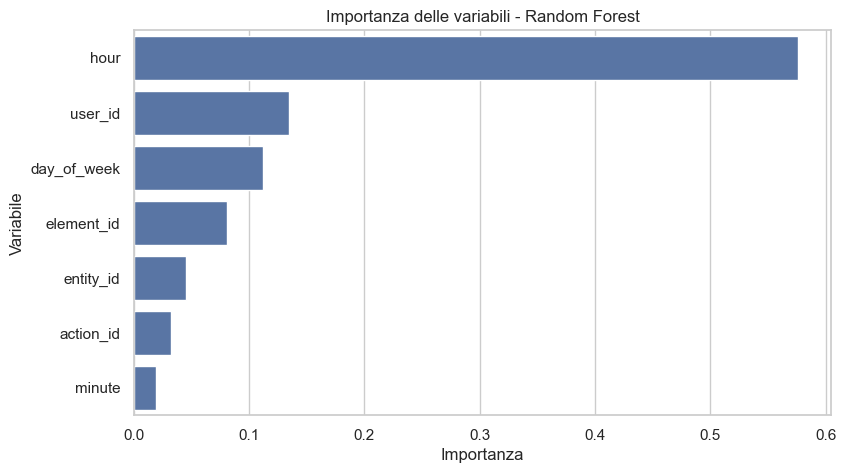

In [41]:
# =========================
# GRÁFICA DE IMPORTANCIA DE VARIABLES
# GRAFICO DELL'IMPORTANZA DELLE VARIABILI
# =========================

plt.figure(figsize=(9, 5))
sns.barplot(data=rf_importance_df, x="importance", y="feature")
plt.title("Importanza delle variabili - Random Forest")
plt.xlabel("Importanza")
plt.ylabel("Variabile")
plt.show()

# La gráfica de importancia de variables del modelo Random Forest muestra que la variable más influyente en la detección de anomalías
# es la hora de la actividad (hour), seguida por el identificador del usuario (user_id) y el día de la semana (day_of_week). 
# Esto confirma que el modelo está captando correctamente los patrones temporales y de comportamiento definidos en las reglas de negocio. 
# En cambio, variables como el minuto exacto, la acción o la entidad tienen una influencia menor en la clasificación final.

# Il grafico dell’importanza delle variabili del modello Random Forest mostra che la variabile più influente nel rilevamento delle anomalie
# è l’ora dell’attività (hour), seguita dall’identificativo dell’utente (user_id) e dal giorno della settimana (day_of_week).
# Questo conferma che il modello sta cogliendo correttamente i pattern temporali e comportamentali definiti nelle regole di business.
# Al contrario, variabili come il minuto esatto, l’azione o l’entità hanno un’influenza minore nella classificazione finale.

In [42]:
# =========================
# COMPARACIÓN ENTRE DECISION TREE Y RANDOM FOREST
# CONFRONTO TRA DECISION TREE E RANDOM FOREST
# =========================

print("DECISION TREE")
print("Accuracy test:", accuracy_score(ya_test, ya_pred))

print("\nRANDOM FOREST")
print("Accuracy test:", accuracy_score(ya_test, ya_pred_rf))

DECISION TREE
Accuracy test: 0.9757607926397736

RANDOM FOREST
Accuracy test: 0.9780166312809625


# CONCLUSIONES FINALES

A lo largo de este proyecto se han cargado, analizado y preparado dos fuentes principales de datos, **Login Log** y **Activity Log**, con el objetivo de construir una primera **PoC de detección de anomalías** en el comportamiento de los usuarios. Para ello, se han transformado las variables temporales más relevantes, generando información útil como la **hora**, el **minuto**, el **día de la semana** y la **duración de la sesión**, lo que ha permitido enriquecer el análisis y preparar correctamente los datos para el modelado.

Uno de los avances más importantes del proyecto ha sido la **integración directa del notebook con la base de datos PostgreSQL y con el archivo `rules.py`**, de forma que tanto el análisis exploratorio como el etiquetado de anomalías y el entrenamiento de modelos utilicen siempre la misma lógica de negocio definida en el sistema. Esto ha permitido evitar inconsistencias entre el notebook, la aplicación de login y el modelo de machine learning, manteniendo un flujo de trabajo unificado y coherente.

A partir de las reglas de negocio definidas, se han implementado criterios de detección para identificar comportamientos anómalos, tales como **logins fuera de la franja horaria habitual del usuario**, accesos realizados **fuera de los días laborables**, actividades ejecutadas **fuera del horario permitido**, accesos a **elementos no autorizados**, acciones sobre **entidades no permitidas** y eventos realizados **fuera del flujo estándar esperado**. De esta manera, se ha construido una base sólida para etiquetar anomalías de forma coherente con el contexto funcional del sistema.

Además, se ha desarrollado un proceso de **generación sintética de datos** para poblar la base de datos con registros de `login_log` y `activity_log` realistas, ajustando progresivamente la proporción de casos normales y anómalos. Este proceso ha requerido varias iteraciones, ya que en un primer momento el porcentaje de anomalías era excesivamente alto y poco realista. Tras revisar tanto las reglas como el generador de datos, se ha conseguido una distribución mucho más coherente, situando el porcentaje de anomalías en torno a un valor razonable para el problema, lo que ha permitido entrenar y evaluar los modelos de forma más consistente.

Sobre esta base, se han entrenado modelos de **Árbol de Decisión** para los datos de login y de actividad, ya que se trata de un enfoque especialmente adecuado para una primera PoC gracias a su **alta interpretabilidad**, su capacidad para **explicar la lógica de clasificación** y su utilidad para presentar resultados de forma clara y defendible ante negocio. Como mejora adicional, se ha incorporado también **Random Forest**, con el fin de reforzar la robustez del sistema. Este modelo ha permitido aportar **mayor estabilidad frente a variaciones del dataset**, **reducir el riesgo de sobreajuste**, **mejorar la capacidad de generalización** en datos no vistos y analizar la relevancia de las variables mediante sus importancias.

Es importante destacar que en este proyecto el **machine learning no sustituye a las reglas de negocio**, sino que las **complementa**. Las reglas permiten detectar anomalías explícitas y conocidas de antemano, mientras que el modelo aporta una segunda capa de análisis capaz de identificar patrones de comportamiento poco habituales o combinaciones sospechosas que no siempre serían fáciles de definir manualmente. De este modo, el sistema combina una capa determinista basada en reglas con una capa predictiva orientada al aprendizaje del comportamiento.

En conjunto, puede concluirse que el **Árbol de Decisión** representa el modelo más adecuado para explicar el comportamiento del sistema y la lógica de negocio, mientras que **Random Forest** constituye una evolución natural del mismo cuando se busca una solución más robusta y orientada a un futuro escenario de producción. Por tanto, el enfoque desarrollado resulta apropiado para una primera fase del proyecto, al combinar **reglas de negocio**, **modelos interpretables**, **datos sintéticos coherentes con el dominio** y una primera mejora orientada a la **robustez predictiva**.

Como líneas de mejora futura, sería recomendable **ampliar el número de usuarios y casuísticas reales**, incorporar **secuencias completas de comportamiento** como `login -> actividad -> logout`, introducir **features agregadas por usuario y por día**, utilizar **datos reales validados por negocio** y evolucionar hacia un **sistema en tiempo real** capaz de bloquear o revisar acciones sospechosas automáticamente. Todo ello permitiría aumentar progresivamente la precisión, la capacidad de detección y la utilidad operativa del sistema en un entorno real.

---

# CONCLUSIONI FINALI

Nel corso di questo progetto sono state caricate, analizzate e preparate due principali fonti di dati, **Login Log** e **Activity Log**, con l’obiettivo di costruire una prima **PoC per il rilevamento delle anomalie** nel comportamento degli utenti. A tal fine, sono state trasformate le variabili temporali più rilevanti, generando informazioni utili come **ora**, **minuto**, **giorno della settimana** e **durata della sessione**, così da arricchire l’analisi e preparare correttamente i dati per il modellamento.

Uno degli avanzamenti più importanti del progetto è stata l’**integrazione diretta del notebook con il database PostgreSQL e con il file `rules.py`**, in modo che sia l’analisi esplorativa sia l’etichettatura delle anomalie e l’addestramento dei modelli utilizzino sempre la stessa logica di business definita nel sistema. Questo ha permesso di evitare incoerenze tra il notebook, l’applicazione di login e il modello di machine learning, mantenendo un flusso di lavoro unificato e coerente.

A partire dalle regole di business definite, sono stati implementati criteri di rilevamento per identificare comportamenti anomali, come **login fuori dalla fascia oraria abituale dell’utente**, accessi effettuati **al di fuori dei giorni lavorativi**, attività eseguite **fuori dall’orario consentito**, accessi a **elementi non autorizzati**, azioni su **entità non consentite** ed eventi effettuati **al di fuori del flusso standard previsto**. In questo modo è stata costruita una base solida per etichettare le anomalie in modo coerente con il contesto funzionale del sistema.

Inoltre, è stato sviluppato un processo di **generazione sintetica dei dati** per popolare il database con record realistici di `login_log` e `activity_log`, regolando progressivamente la proporzione tra casi normali e anomali. Questo processo ha richiesto varie iterazioni, poiché inizialmente la percentuale di anomalie risultava eccessivamente alta e poco realistica. Dopo aver rivisto sia le regole sia il generatore di dati, si è ottenuta una distribuzione molto più coerente, portando la percentuale di anomalie a un valore ragionevole per il problema e consentendo così di addestrare e valutare i modelli in modo più consistente.

Su questa base, sono stati addestrati modelli di **Albero di Decisione** per i dati di login e di activity, poiché si tratta di un approccio particolarmente adatto a una prima PoC grazie alla sua **elevata interpretabilità**, alla capacità di **spiegare chiaramente la logica di classificazione** e alla sua utilità nel presentare risultati in modo comprensibile e difendibile dal punto di vista del business. Come miglioramento aggiuntivo, è stato inoltre introdotto **Random Forest**, con l’obiettivo di rafforzare la robustezza del sistema. Questo modello ha permesso di ottenere **maggiore stabilità rispetto alle variazioni del dataset**, **minore rischio di overfitting**, **migliore capacità di generalizzazione** su dati non visti e la possibilità di analizzare la rilevanza delle variabili attraverso le rispettive importanze.

È importante sottolineare che in questo progetto il **machine learning non sostituisce le regole di business**, ma le **completa**. Le regole permettono di rilevare anomalie esplicite e note in anticipo, mentre il modello aggiunge un secondo livello di analisi capace di identificare pattern di comportamento poco abituali o combinazioni sospette che non sempre sarebbero facili da definire manualmente. In questo modo il sistema combina un livello deterministico basato su regole con un livello predittivo orientato all’apprendimento del comportamento.

Nel complesso, si può concludere che l’**Albero di Decisione** rappresenta il modello più adatto per spiegare il comportamento del sistema e la logica di business, mentre **Random Forest** costituisce una sua naturale evoluzione quando si desidera una soluzione più robusta e orientata a un futuro scenario di produzione. Di conseguenza, l’approccio sviluppato risulta appropriato per una prima fase del progetto, in quanto combina **regole di business**, **modelli interpretabili**, **dati sintetici coerenti con il dominio** e un primo miglioramento orientato alla **robustezza predittiva**.

Come possibili sviluppi futuri, sarebbe consigliabile **ampliare il numero di utenti e di casistiche reali**, includere **sequenze complete di comportamento** come `login -> attività -> logout`, introdurre **feature aggregate per utente e per giorno**, utilizzare **dati reali validati dal business** ed evolvere verso un **sistema in tempo reale** capace di bloccare o sottoporre a revisione automatica le azioni sospette. Tutto ciò permetterebbe di aumentare progressivamente la precisione, la capacità di rilevamento e l’utilità operativa del sistema in un contesto reale.

En este proyecto, el machine learning se usa para complementar las reglas, no para sustituirlas.

Las reglas detectan anomalías obvias porque están definidas previamente.
El machine learning sirve para aprender patrones de comportamiento y detectar casos raros que no están escritos explícitamente en una regla.